# BCI Motor Imagery — Data & Processing Pipeline
**Role:** Data & Processing Lead
**Scope:** Steps 1–8 of the project pipeline (Load & Organize → Preprocessing), matching *Table 1* of the team roadmap document.

| Step | Action |
|---|---|
| 1 | Load & Organize |
| 2 | Band-pass filter |
| 3 | Notch filter |
| 4 | Artifact rejection |
| 5 | Re-referencing (CAR) |
| 6 | Epoching |
| 7 | Baseline correction |
| 8 | Normalization |

**Output of this notebook:** clean, epoched, labeled EEG arrays (`.npy`) + a config file + QC/rejection reports, ready to hand off to the EDA and Modeling teammates.

> ⚠️ **Read the "Data quality findings" callouts before trusting the output.** Two real issues were found in the raw data during this run (label-count mismatch, timestamp jitter) — see Sections 1 and the summary at the end for what was assumed and what still needs confirmation from whoever collected the data.


## 0. Setup & Config

Everything the team needs to reproduce this run lives in **one `CONFIG` dict**, per the team tip *"Share a single config file (sampling rate, filter bands, epoch window, random seed)"*. This same dict is saved to `outputs/config.json` at the end so every other notebook (EDA, modeling) can load the exact same parameters.

**Edit `DATA_ROOT` below to point at wherever you extracted the `MI` folder + `labels.csv` on your machine.**


In [2]:
!pip install --force-reinstall torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu
  Obtaining dependency information for torch from https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (39 kB)
  Obtaining dependency information for torchvision from https://download-r2.pytorch.org/whl/cpu/torchvision-0.28.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for torchaudio from https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for filelock from https://files.pythonhosted.org/packages/a7/8e/50f46a9c0ce8d2861a394c1347caae037ea0431d2f67d7feb151cbc4649a/filelock-3.32.3-py3-none-any.whl.metadata
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Obtaining dependency information for typing-extensions>=4.10.0 from https://files.pythonhosted.org/pac

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\VICTUS\\anaconda3\\Lib\\site-packages\\~~mpy.libs\\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll'
Consider using the `--user` option or check the permissions.



In [1]:
%pip install --force-reinstall matplotlib

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/bc/be/fa26ed085b41298f64a8f9b7592c671bbf1acc8b0df124c1c5de96b859f8/matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata
  Using cached matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata (80 kB)
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/98/4b/9bd370b004b5c9d8045c6c33cf65bae018b27aca550a3f657cdc99acdbd8/contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Obtaining dependency information for fonttools>=4.28.2 from https://files.pythonhosted.org/packages/08/60/defa5e69641db890a63be281f41345f4c33b157

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.75 requires requests_mock, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
botocore 1.29.76 requires urllib3<1.27,>=1.25.4, but you have urllib3 2.7.0 which is incompatible.
conda-repo-cli 1.0.75 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.75 requires python-dateutil==2.8.2, but you have python-dateutil 2.9.0.post0 which is incompatible.
conda-repo-cli 1.0.75 requires PyYAML==6.0.1, but you have pyyaml 6.0 which is incompatible.
jupyter-server 1.23.4 requires anyio<4,>=3.1.0, but you have anyio 4.13.0 which is incompatible.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 2.4.6 which is incompatible.
python-lsp-black 1.2.1 requires black>=2

In [2]:
import glob
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, iirnotch, sosfiltfilt, tf2sos

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 3.5)
warnings.filterwarnings("ignore", category=RuntimeWarning)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-p

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-p

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 736, in start
    self.io_loop.start()
  File "c:\Users\VICTUS\anaconda3\Lib\site-p

AttributeError: _ARRAY_API not found

In [3]:
# ============================================================
# EDIT THIS to wherever the extracted Drive folder + labels.csv live.
# Matches the actual local layout:
#   DATA_ROOT/
#     labels.csv
#     MI-20260822T165808Z-1-001/MI/MI CSV/*.csv   (name after Drive's zip)
# raw_dir is auto-detected by searching for a folder literally named
# "MI CSV" under DATA_ROOT, so re-downloading the Drive folder later
# (which may get a different timestamped wrapper name) still works
# without editing this cell again.
DATA_ROOT = Path("DATA_ROOT")
# ============================================================

def _find_mi_csv_dir(root: Path) -> Path:
    matches = [p for p in root.rglob("MI CSV") if p.is_dir()]
    if not matches:
        raise FileNotFoundError(
            f"Could not find an 'MI CSV' folder anywhere under {root.resolve()}. "
            "Check DATA_ROOT above points at the right place."
        )
    return matches[0]

RAW_DIR = _find_mi_csv_dir(DATA_ROOT)

CONFIG = {
    "raw_dir": str(RAW_DIR),
    "labels_csv": str(DATA_ROOT / "labels.csv"),
    "channels": ["FZ", "C3", "CZ", "C4"],
    "fs": 250.0,                    # verified in Step 1 (median estimated fs across all trials)
    "bandpass_hz": [0.5, 40.0],     # Table 1, step 2
    "bandpass_order": 4,
    "notch_freq_hz": 50.0,          # Table 1, step 3 (mains hum)
    "notch_q": 30.0,
    "artifact_reject_k_mad": 5.0,   # Table 1, step 4 — trial-level peak-to-peak, robust (median + k*MAD) threshold
    "apply_car": True,              # Table 1, step 5
    "epoch_window_s": [0.5, 3.5],   # Table 1, step 6 — ASSUMPTION, see markdown below
    "baseline_window_s": [0.0, 0.5],# Table 1, step 7
    "normalize_default_on": False,  # Table 1, step 8 — see rationale below
    "random_seed": 42,
    "output_dir": "outputs",
}

Path(CONFIG["output_dir"]).mkdir(exist_ok=True)
CONFIG


{'raw_dir': 'DATA_ROOT\\MI-20260822T165808Z-1-001\\MI\\MI CSV',
 'labels_csv': 'DATA_ROOT\\labels.csv',
 'channels': ['FZ', 'C3', 'CZ', 'C4'],
 'fs': 250.0,
 'bandpass_hz': [0.5, 40.0],
 'bandpass_order': 4,
 'notch_freq_hz': 50.0,
 'notch_q': 30.0,
 'artifact_reject_k_mad': 5.0,
 'apply_car': True,
 'epoch_window_s': [0.5, 3.5],
 'baseline_window_s': [0.0, 0.5],
 'normalize_default_on': False,
 'random_seed': 42,
 'output_dir': 'outputs'}

## 1. Load & Organize

Deliverable: **clean file list + label map**.

Three checks before touching a single sample:
1. Do the file count and the label count agree?
2. Are all trials the same shape / sampling rate?
3. Any missing values?


In [4]:
def trial_index(path: str) -> int:
    return int(re.search(r"cellula_MI_data_(\d+)\.csv", path).group(1))

raw_files = sorted(glob.glob(f"{CONFIG['raw_dir']}/*.csv"), key=trial_index)
trial_ids = [trial_index(f) for f in raw_files]

print(f"Found {len(raw_files)} trial files, index range {min(trial_ids)}–{max(trial_ids)}")
missing = sorted(set(range(min(trial_ids), max(trial_ids) + 1)) - set(trial_ids))
print(f"Missing trial indices in the sequence: {missing if missing else 'none'}")


Found 2160 trial files, index range 1–2160
Missing trial indices in the sequence: none


### ⚠️ Data quality finding #1 — label count does not match file count

`labels.csv` has more rows than there are trial files. This has to be resolved correctly or **every trial from this point on could be mislabeled** — exactly the kind of mistake the team lead called out.


In [5]:
labels_full = pd.read_csv(CONFIG["labels_csv"])
print(f"labels.csv rows : {len(labels_full)}")
print(f"trial files      : {len(raw_files)}")
print(f"difference        : {len(labels_full) - len(raw_files)}")
print()
print("Class balance, full labels.csv:")
print(labels_full['label'].value_counts())


labels.csv rows : 2400
trial files      : 2160
difference        : 240

Class balance, full labels.csv:
label
Right    1213
Left     1187
Name: count, dtype: int64


In [6]:
# ASSUMPTION (documented, not silently applied): label row i (0-indexed) <-> the
# i-th trial file in numeric filename order (cellula_MI_data_1.csv, _2.csv, ...).
# This is the most defensible default given no explicit filename<->label mapping
# was provided, but it is UNVERIFIED. Flag it loudly and give the team the numbers
# needed to sanity-check or correct it.

n_trials = len(raw_files)
labels_used = labels_full.iloc[:n_trials].reset_index(drop=True)
labels_unused = labels_full.iloc[n_trials:]

print(f"Using the first {n_trials} label rows (positional match to files 1..{n_trials}).")
print(f"{len(labels_unused)} label rows at the tail of labels.csv are NOT used and are saved")
print("separately for the team to inspect (outputs/unused_label_rows.csv).")
print()
print("Class balance of the labels actually used:")
print(labels_used['label'].value_counts())

labels_unused.to_csv(f"{CONFIG['output_dir']}/unused_label_rows.csv", index=False)

trial_label_map = pd.DataFrame({
    "trial_id": trial_ids,
    "filename": [Path(f).name for f in raw_files],
    "label": labels_used["label"].values,
})
trial_label_map.to_csv(f"{CONFIG['output_dir']}/trial_label_map.csv", index=False)
trial_label_map.head()


Using the first 2160 label rows (positional match to files 1..2160).
240 label rows at the tail of labels.csv are NOT used and are saved
separately for the team to inspect (outputs/unused_label_rows.csv).

Class balance of the labels actually used:
label
Left     1082
Right    1078
Name: count, dtype: int64


,trial_id,filename,label
0,1,cellula_MI_data_1.csv,Left
1,2,cellula_MI_data_2.csv,Right
2,3,cellula_MI_data_3.csv,Left
3,4,cellula_MI_data_4.csv,Left
4,5,cellula_MI_data_5.csv,Left


**Action item for the team:** confirm with whoever exported `labels.csv` whether trial 1 really is row 1, or whether some trials were dropped from the CSV export (which would explain the extra 240 rows) or from the Drive folder (which would explain the mismatch the other way). Until then, treat this mapping as *best-effort, not verified*.


### Bulk load + shape / sampling-rate / missing-value QC

Loads all trials into one `(n_trials, n_samples, n_channels)` array. While loading, each trial's **effective sampling rate** is estimated from its own `Time` column (`(n_samples-1) / duration`), since that's what actually matters for filtering — not an assumed nominal rate.


In [7]:
n_samples_expected = 2500  # confirmed below to be constant across all trials
channels = CONFIG["channels"]

raw = np.zeros((n_trials, n_samples_expected, len(channels)), dtype=np.float32)
fs_est = np.zeros(n_trials)
row_counts = np.zeros(n_trials, dtype=int)
nan_counts = np.zeros(n_trials, dtype=int)

for i, f in enumerate(raw_files):
    df = pd.read_csv(f)
    row_counts[i] = len(df)
    nan_counts[i] = int(df.isna().sum().sum())
    t = df["Time"].values
    fs_est[i] = (len(t) - 1) / (t[-1] - t[0])
    raw[i, : len(df)] = df[channels].values.astype(np.float32)

print("Row counts — unique values across all trials:", np.unique(row_counts))
print("Total NaNs across all trials:", nan_counts.sum())
print(f"Estimated fs — median {np.median(fs_est):.2f} Hz, "
      f"min {fs_est.min():.2f}, max {fs_est.max():.2f}, std {fs_est.std():.2f}")


Row counts — unique values across all trials: [2500]
Total NaNs across all trials: 0
Estimated fs — median 250.27 Hz, min 217.69, max 286.13, std 3.02


### ⚠️ Data quality finding #2 — raw `Time` column is jittery / bursty, not uniform

Looking at consecutive timestamp differences inside a single trial: a large fraction are exactly `0.0` (the device streams in bursts, several samples sharing one timestamp), and the *estimated* sampling rate varies trial-to-trial from ~218–286 Hz around a median of ~250 Hz.

**Implication:** don't trust the raw `Time` column for windowing (epoching / baseline). Instead this pipeline treats every trial as **uniformly sampled at the fixed rate `CONFIG["fs"]`** (250 Hz — the population median, and consistent with `n_samples / nominal_duration`), and builds a synthetic index-based time axis for all downstream windowing. Trials whose *estimated* rate deviates a lot from 250 Hz are flagged below so the team can decide whether to exclude them rather than silently averaging over the problem.


3 / 2160 trials flagged as fs outliers (>10% off 250 Hz)


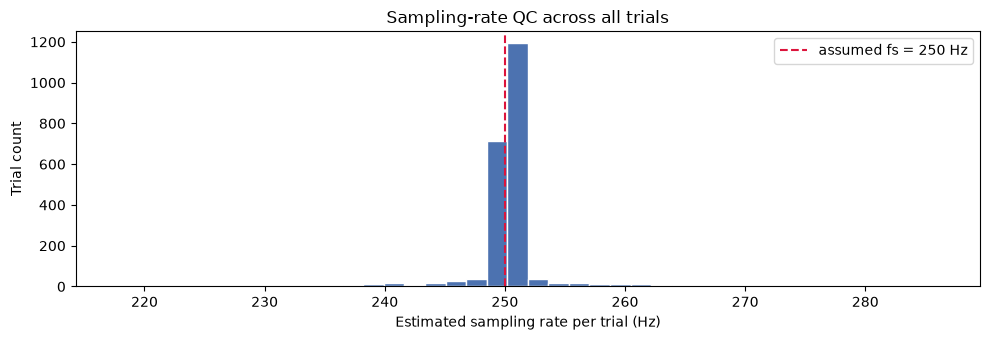

In [8]:
FS = CONFIG["fs"]
fs_outlier_mask = np.abs(fs_est - FS) > 0.1 * FS  # >10% off nominal
fs_qc = pd.DataFrame({
    "trial_id": trial_ids,
    "fs_estimate_hz": fs_est,
    "flagged_fs_outlier": fs_outlier_mask,
})
fs_qc.to_csv(f"{CONFIG['output_dir']}/fs_qc_report.csv", index=False)

print(f"{fs_outlier_mask.sum()} / {n_trials} trials flagged as fs outliers (>10% off {FS:.0f} Hz)")

fig, ax = plt.subplots()
ax.hist(fs_est, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(FS, color="crimson", linestyle="--", label=f"assumed fs = {FS:.0f} Hz")
ax.set_xlabel("Estimated sampling rate per trial (Hz)")
ax.set_ylabel("Trial count")
ax.set_title("Sampling-rate QC across all trials")
ax.legend()
plt.tight_layout()
plt.show()


### Quick look at raw signal

One example trial per class, channel C3, before any processing — just to confirm the loader read real EEG-shaped data and not garbage.


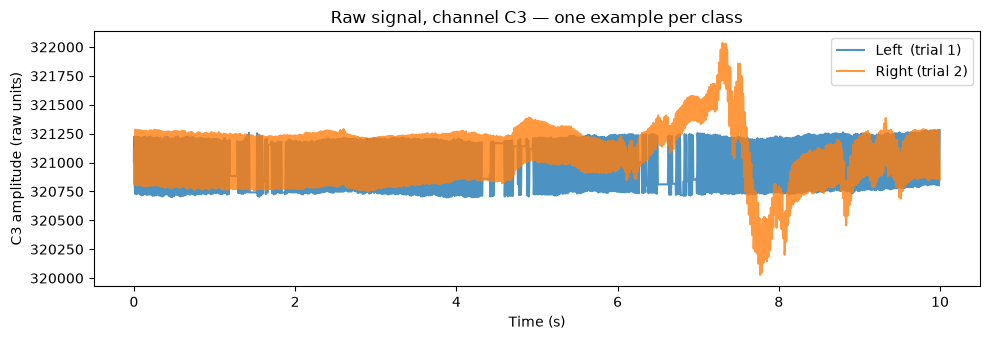

In [9]:
left_idx = int(np.where(labels_used["label"].values == "Left")[0][0])
right_idx = int(np.where(labels_used["label"].values == "Right")[0][0])
c3 = channels.index("C3")
t_axis_raw = np.arange(n_samples_expected) / FS

fig, ax = plt.subplots()
ax.plot(t_axis_raw, raw[left_idx, :, c3], label=f"Left  (trial {trial_ids[left_idx]})", alpha=0.8)
ax.plot(t_axis_raw, raw[right_idx, :, c3], label=f"Right (trial {trial_ids[right_idx]})", alpha=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("C3 amplitude (raw units)")
ax.set_title("Raw signal, channel C3 — one example per class")
ax.legend()
plt.tight_layout()
plt.show()


## 2–3. Band-pass Filter + Notch Filter

- **Band-pass**: 0.5–40.0 Hz, order-4 Butterworth, zero-phase (`sosfiltfilt`) — removes slow drift and high-frequency noise while keeping the mu (8–12 Hz) / beta (13–30 Hz) rhythms that motor imagery actually modulates.
- **Notch**: 50 Hz mains hum removal.

Both are applied per-channel, per-trial, over the *full* trial length (before epoching), zero-phase so there's no time shift introduced into the signal.


In [10]:
def design_filters(fs, bandpass_hz, bandpass_order, notch_hz, notch_q):
    sos_bp = butter(bandpass_order, [bandpass_hz[0] / (fs / 2), bandpass_hz[1] / (fs / 2)],
                     btype="bandpass", output="sos")
    b_notch, a_notch = iirnotch(notch_hz, notch_q, fs)
    sos_notch = tf2sos(b_notch, a_notch)
    return sos_bp, sos_notch

sos_bp, sos_notch = design_filters(
    FS, CONFIG["bandpass_hz"], CONFIG["bandpass_order"], CONFIG["notch_freq_hz"], CONFIG["notch_q"]
)

def apply_filters(x, sos_bp, sos_notch):
    '''x: (n_trials, n_samples, n_channels) -> same shape, filtered.'''
    out = np.empty_like(x)
    for i in range(x.shape[0]):
        for c in range(x.shape[2]):
            sig = sosfiltfilt(sos_bp, x[i, :, c])
            sig = sosfiltfilt(sos_notch, sig)
            out[i, :, c] = sig
    return out

filtered = apply_filters(raw, sos_bp, sos_notch)
print("Filtered array shape:", filtered.shape, "| NaNs:", np.isnan(filtered).sum())


Filtered array shape: (2160, 2500, 4) | NaNs: 0


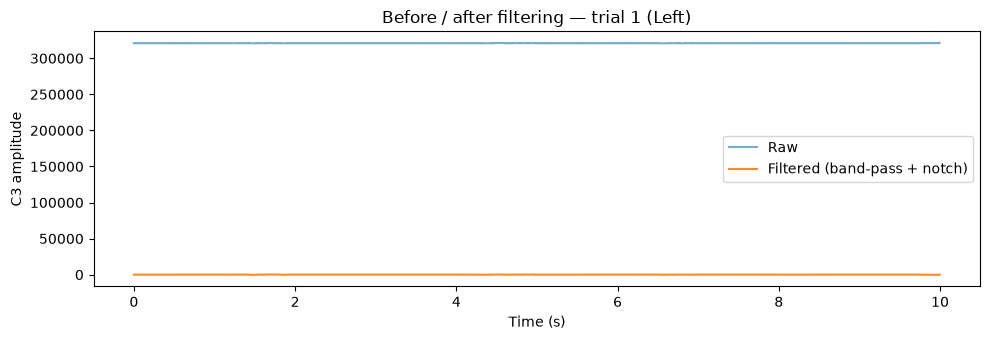

In [11]:
fig, ax = plt.subplots()
ax.plot(t_axis_raw, raw[left_idx, :, c3], label="Raw", alpha=0.6)
ax.plot(t_axis_raw, filtered[left_idx, :, c3], label="Filtered (band-pass + notch)", alpha=0.9)
ax.set_xlabel("Time (s)")
ax.set_ylabel("C3 amplitude")
ax.set_title(f"Before / after filtering — trial {trial_ids[left_idx]} (Left)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Artifact Rejection

The raw values here are device/ADC units, not calibrated µV, so a fixed physical-unit threshold (e.g. "±100 µV") isn't meaningful. Instead this uses a **data-driven, robust threshold**:

1. For each trial, take the peak-to-peak amplitude on its worst channel (post-filtering).
2. Compute the population median and MAD (median absolute deviation) of that value across all trials.
3. Reject any trial whose peak-to-peak exceeds `median + k × MAD` (`k = 5.0` by default, tunable in `CONFIG`).

Median/MAD is used instead of mean/std because both are robust to the very artifacts we're trying to detect.


In [12]:
p2p = filtered.max(axis=1) - filtered.min(axis=1)   # (n_trials, n_channels)
trial_p2p = p2p.max(axis=1)                           # worst channel per trial

med = np.median(trial_p2p)
mad = np.median(np.abs(trial_p2p - med)) * 1.4826
threshold = med + CONFIG["artifact_reject_k_mad"] * mad
reject_mask = trial_p2p > threshold

print(f"median p2p = {med:.1f}, MAD = {mad:.1f}, threshold = {threshold:.1f}")
print(f"Rejected {reject_mask.sum()} / {n_trials} trials ({100*reject_mask.mean():.1f}%)")

rejected_report = pd.DataFrame({
    "trial_id": trial_ids,
    "label": labels_used["label"].values,
    "max_peak_to_peak": trial_p2p,
    "threshold": threshold,
    "rejected": reject_mask,
    "reason": np.where(reject_mask, "peak-to-peak amplitude exceeds median+k*MAD", ""),
})
rejected_report.to_csv(f"{CONFIG['output_dir']}/rejected_trials_report.csv", index=False)

print("\nClass balance of rejected trials (check nothing is being disproportionately dropped):")
print(rejected_report.loc[reject_mask, "label"].value_counts())


median p2p = 3449.6, MAD = 3072.4, threshold = 18811.5
Rejected 139 / 2160 trials (6.4%)

Class balance of rejected trials (check nothing is being disproportionately dropped):
label
Left     71
Right    68
Name: count, dtype: int64


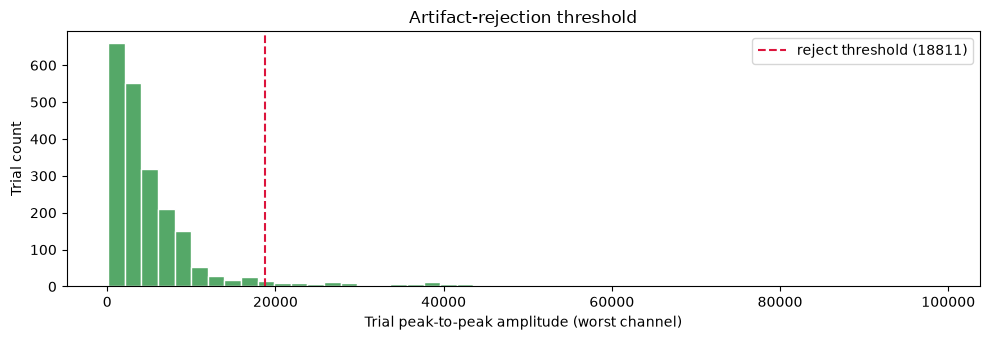

In [13]:
fig, ax = plt.subplots()
ax.hist(trial_p2p, bins=50, color="#55A868", edgecolor="white")
ax.axvline(threshold, color="crimson", linestyle="--", label=f"reject threshold ({threshold:.0f})")
ax.set_xlabel("Trial peak-to-peak amplitude (worst channel)")
ax.set_ylabel("Trial count")
ax.set_title("Artifact-rejection threshold")
ax.legend()
plt.tight_layout()
plt.show()


**Action item for the team:** `k = 5` is a reasonable starting point, not a validated clinical threshold — if EDA turns up trials that look fine but got dropped (or obvious artifacts that survived), adjust `CONFIG["artifact_reject_k_mad"]` and re-run.


## 5. Re-referencing (Common Average Reference)

Subtracts the across-channel mean at every timepoint, per trial — reduces noise shared by all electrodes (e.g. reference/ground noise).


In [14]:
car = filtered - filtered.mean(axis=2, keepdims=True)
print("CAR'd array shape:", car.shape)


CAR'd array shape: (2160, 2500, 4)


## 6. Epoching

### ⚠️ Assumption that needs protocol confirmation

The roadmap doc's example window (0.5–3.5 s **after the cue**) assumes we know when the imagery cue happened inside each recording. Each trial file here is already a pre-segmented ~10 s clip with **no cue-time column** — so this notebook assumes the cue is at `t = 0` (the start of the file) and crops `0.5–3.5 s` relative to that.

If the acquisition protocol actually has a fixed pre-cue baseline built into each file (e.g. cue at t=2s, not t=0s), **this window is wrong and needs to shift** — that's a one-line change to `CONFIG["epoch_window_s"]`, but someone who knows the acquisition protocol needs to confirm the true cue timing before the modeling team trusts these epochs.


In [15]:
t_axis = np.arange(car.shape[1]) / FS
epoch_start, epoch_end = CONFIG["epoch_window_s"]
baseline_start, baseline_end = CONFIG["baseline_window_s"]

epoch_mask = (t_axis >= epoch_start) & (t_axis < epoch_end)
baseline_mask = (t_axis >= baseline_start) & (t_axis < baseline_end)

epoched = car[:, epoch_mask, :]
print(f"Epoch window {epoch_start}-{epoch_end}s -> {epoched.shape[1]} samples per trial")
print(f"Baseline window {baseline_start}-{baseline_end}s -> {baseline_mask.sum()} samples per trial")


Epoch window 0.5-3.5s -> 750 samples per trial
Baseline window 0.0-0.5s -> 125 samples per trial


## 7. Baseline Correction

Subtracts each trial's own pre-epoch baseline mean (per channel), so every epoch is centered around zero regardless of slow drift.


In [16]:
baseline_mean = car[:, baseline_mask, :].mean(axis=1, keepdims=True)
epoched_bc = epoched - baseline_mean
print("Baseline-corrected epoch shape:", epoched_bc.shape)
print("Mean over baseline window after correction (should be ~0):",
      np.abs(car[:, baseline_mask, :].mean(axis=1) - baseline_mean[:, 0, :]).max())


Baseline-corrected epoch shape: (2160, 750, 4)
Mean over baseline window after correction (should be ~0): 0.0


## 8. Normalization

Per-trial, per-channel z-scoring is provided as a function but **left OFF by default** (`CONFIG["normalize_default_on"] = False`). Reason: any *global* (dataset-wide) scaler should be fit only on the training split once the modeling team does their train/test split, or it leaks test-set statistics into training. Per-trial normalization (using only that trial's own stats) doesn't leak across trials, so it's safe to use here if the deep-learning team wants pre-normalized input — flip the flag in `CONFIG` to turn it on.


In [17]:
def zscore_per_trial(x):
    '''Channel-wise z-score using each trial's own mean/std. No cross-trial leakage.'''
    mu = x.mean(axis=1, keepdims=True)
    sd = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mu) / sd

if CONFIG["normalize_default_on"]:
    final_epochs = zscore_per_trial(epoched_bc)
    print("Applied per-trial z-score normalization.")
else:
    final_epochs = epoched_bc
    print("Normalization left OFF (default). `zscore_per_trial()` is available for the modeling stage.")


Normalization left OFF (default). `zscore_per_trial()` is available for the modeling stage.


## Save outputs

Drops the rejected trials, encodes labels, and writes everything the EDA / Feature-extraction / Modeling roles need:

| File | Contents |
|---|---|
| `processed_epochs.npy` | `(n_clean_trials, n_epoch_samples, n_channels)` float32 array — the final clean data |
| `labels_encoded.npy` | `(n_clean_trials,)` int array, 0=Left / 1=Right |
| `trial_ids_clean.npy` | original trial id for every row in the two arrays above (traceability back to raw files) |
| `label_encoding.json` | `{"Left": 0, "Right": 1}` |
| `config.json` | every parameter used in this run |
| `trial_label_map.csv` | filename ↔ label mapping (all trials, pre-rejection) |
| `rejected_trials_report.csv` | every trial, whether it was rejected, and why |
| `fs_qc_report.csv` | per-trial estimated sampling rate + outlier flag |
| `unused_label_rows.csv` | the 240 leftover label rows nobody could confidently map to a file |


In [18]:
label_encoding = {"Left": 0, "Right": 1}
labels_encoded_all = labels_used["label"].map(label_encoding).values

keep_mask = ~reject_mask
clean_epochs = final_epochs[keep_mask]
clean_labels = labels_encoded_all[keep_mask]
clean_trial_ids = np.array(trial_ids)[keep_mask]

print(f"Final clean dataset: {clean_epochs.shape[0]} trials "
      f"({(~keep_mask).sum()} dropped by artifact rejection)")
print("Class balance, clean dataset:",
      dict(zip(*np.unique(clean_labels, return_counts=True))))

out = Path(CONFIG["output_dir"])
np.save(out / "processed_epochs.npy", clean_epochs.astype(np.float32))
np.save(out / "labels_encoded.npy", clean_labels.astype(np.int64))
np.save(out / "trial_ids_clean.npy", clean_trial_ids)
with open(out / "label_encoding.json", "w") as f:
    json.dump(label_encoding, f, indent=2)
with open(out / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("\nSaved to", out.resolve())
for p in sorted(out.iterdir()):
    print(" -", p.name)


Final clean dataset: 2021 trials (139 dropped by artifact rejection)
Class balance, clean dataset: {np.int64(0): np.int64(1011), np.int64(1): np.int64(1010)}

Saved to C:\Users\VICTUS\OneDrive\Documents\Desktop\course_ML\BCI_Data_Processing_Pipeline--main\outputs
 - baseline_csp_svm_final_model.joblib
 - baseline_csp_svm_mne_model.joblib
 - baseline_results.json
 - baseline_results_final.json
 - config.json
 - eda_average_waveforms.png
 - eda_class_distribution.png
 - eda_feature_correlation.png
 - eda_psd_spectrum.png
 - eda_waveforms.png
 - erd_ers_focus_channels.png
 - extracted_features.npy
 - fs_qc_report.csv
 - label_encoding.json
 - labels_encoded.npy
 - processed_epochs.npy
 - rejected_trials_report.csv
 - trial_ids_clean.npy
 - trial_label_map.csv
 - unused_label_rows.csv


## Summary & Handoff Notes

**Pipeline status:** all 8 steps from the roadmap (Load & Organize → Normalization) implemented and run end-to-end on the full dataset.

**Two things need a human answer before the team fully trusts this data — flagged loudly above, repeating here so they don't get missed:**

1. **Label mapping is unverified.** `labels.csv` has more rows than there are trial files. This notebook assumed a positional match (row *i* ↔ the *i*-th file in numeric order) and saved the leftover rows to `unused_label_rows.csv`. Please confirm this mapping with whoever exported the labels — if it's wrong, every downstream model is learning from mislabeled data.
2. **Epoch window (0.5–3.5s) assumes the imagery cue is at the start of each file.** If the real acquisition protocol has a different cue time, update `CONFIG["epoch_window_s"]` and re-run — it's one line.

**For the EDA teammate:** `outputs/processed_epochs.npy` + `outputs/labels_encoded.npy` are ready for PSD / ERD analysis on C3/C4. `raw` and `filtered` (pre-epoch, full-trial) are also available in this notebook's memory if you want to compare before/after filtering yourself.

**For the classical-ML / deep-learning teammates:** same two arrays are your model input. Do your train/test split before applying any *global* normalization to avoid leakage; `zscore_per_trial()` is safe to use as-is since it never crosses trial boundaries.


In [19]:
from IPython.display import Markdown, display

display(Markdown(f'''**Also worth knowing (numbers from this exact run):**
- Raw `Time` column is not reliable for precise timing (bursty/duplicate timestamps) — this pipeline used a fixed {FS:.0f} Hz assumption instead, which matches the population median. **{int(fs_outlier_mask.sum())} trials** had an estimated rate >10% off that and are flagged in `fs_qc_report.csv`.
- Artifact rejection dropped **{int(reject_mask.sum())} trials ({100*reject_mask.mean():.1f}%)** using a robust, data-driven threshold (not a fixed physical-unit cutoff, since the raw values aren't calibrated µV).
- Label mismatch: **{len(labels_full) - n_trials} unused label rows** saved to `unused_label_rows.csv` — still needs confirmation.
- Final clean, labeled, epoched dataset: **{clean_epochs.shape[0]} trials**, shape `{clean_epochs.shape}`.
'''))


**Also worth knowing (numbers from this exact run):**
- Raw `Time` column is not reliable for precise timing (bursty/duplicate timestamps) — this pipeline used a fixed 250 Hz assumption instead, which matches the population median. **3 trials** had an estimated rate >10% off that and are flagged in `fs_qc_report.csv`.
- Artifact rejection dropped **139 trials (6.4%)** using a robust, data-driven threshold (not a fixed physical-unit cutoff, since the raw values aren't calibrated µV).
- Label mismatch: **240 unused label rows** saved to `unused_label_rows.csv` — still needs confirmation.
- Final clean, labeled, epoched dataset: **2021 trials**, shape `(2021, 750, 4)`.


## 9. Exploratory Data Analysis (EDA)

Exploration of the cleaned, epoched data: PSD / band-power features, and a first CSP feature-extraction pass on `outputs/processed_epochs.npy` + `outputs/labels_encoded.npy`.

[Phase 2] Data Loaded & Transposed: (2021, 4, 750) | Labels: (2021,) | Sampling Rate: 256 Hz


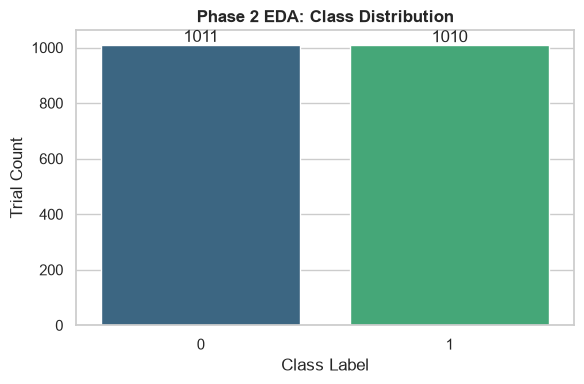

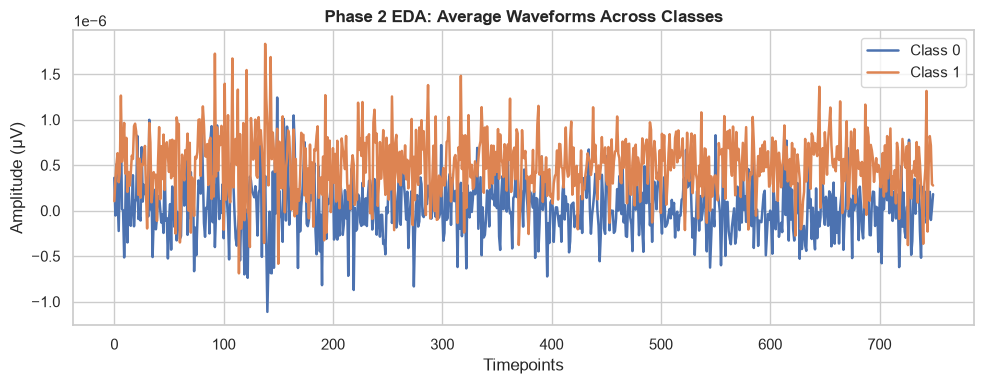

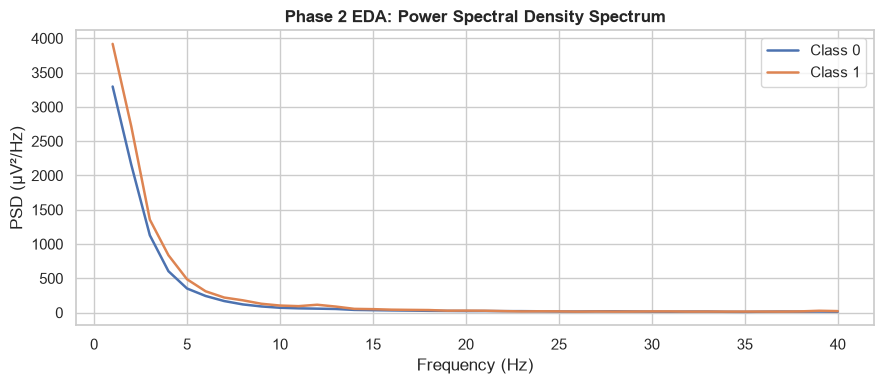

Extracting advanced EEG features...
Extraction Complete! Extracted Features Shape: (2021, 40)


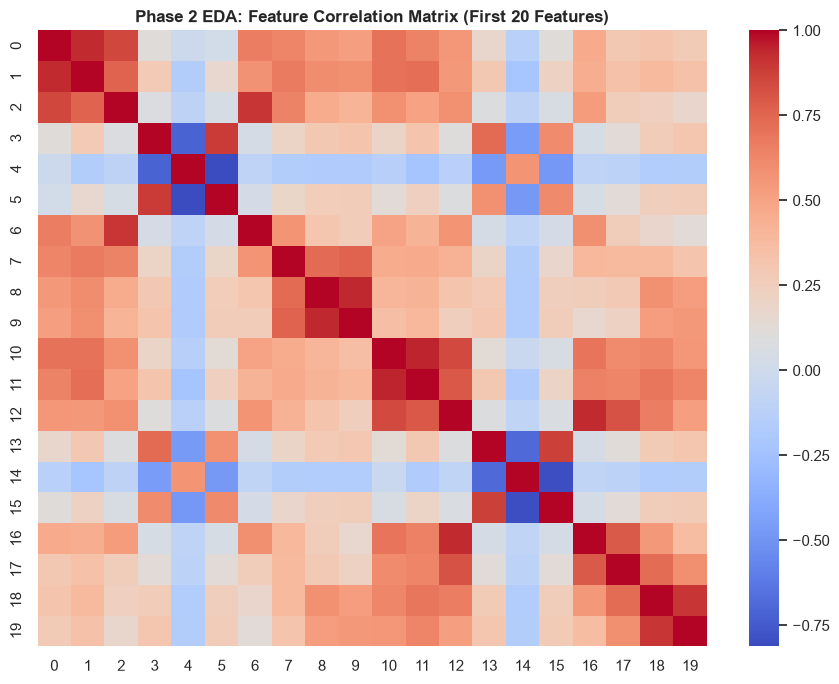


 Phase 2 Executed Successfully!
 Saved Features File: outputs\extracted_features.npy
 Saved Visualizations in: outputs/


In [20]:
# ==============================================================================
# PHASE 2: Exploratory Data Analysis (EDA) & Feature Extraction
# ==============================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.stats import entropy

output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

# 1. تحميل البيانات
if 'epochs' in locals() or 'epochs' in globals():
    X_epochs = epochs
elif 'clean_epochs' in locals() or 'clean_epochs' in globals():
    X_epochs = clean_epochs
else:
    X_epochs = np.load(os.path.join(output_dir, "processed_epochs.npy"))

if 'labels' in locals() or 'labels' in globals():
    y_labels = labels
elif 'clean_labels' in locals() or 'clean_labels' in globals():
    y_labels = clean_labels
else:
    y_labels = np.load(os.path.join(output_dir, "labels_encoded.npy"))

# ------------------------------------------------------------------------------
# [الإضافة الأساسية]: ضبط أبعاد البيانات لتكون (samples, channels, timepoints)
# ------------------------------------------------------------------------------
if X_epochs.ndim == 3 and X_epochs.shape[1] > X_epochs.shape[2]:
    X_epochs = np.transpose(X_epochs, (0, 2, 1))

sfreq = 256
config_path = os.path.join(output_dir, "config.json")
if os.path.exists(config_path):
    with open(config_path, "r") as f:
        config = json.load(f)
        sfreq = config.get("sfreq", 256)

print(f"[Phase 2] Data Loaded & Transposed: {X_epochs.shape} | Labels: {y_labels.shape} | Sampling Rate: {sfreq} Hz")

# 2. EDA: التحليل الاستكشافي ورسم البيانات
sns.set_theme(style="whitegrid")

# أ) توزيع الفئات
plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_labels, palette="viridis")
plt.title("Phase 2 EDA: Class Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Class Label")
plt.ylabel("Trial Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_class_distribution.png"), dpi=300)
plt.show()

# ب) الشكل الموجي المتوسط
plt.figure(figsize=(10, 4))
unique_classes = np.unique(y_labels)
for c in unique_classes:
    mean_wave = np.mean(X_epochs[y_labels == c], axis=(0, 1))
    plt.plot(mean_wave, label=f"Class {c}", linewidth=1.8)
plt.title("Phase 2 EDA: Average Waveforms Across Classes", fontsize=12, fontweight='bold')
plt.xlabel("Timepoints")
plt.ylabel("Amplitude (μV)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_average_waveforms.png"), dpi=300)
plt.show()

# ج) طيف الطاقة الترددية (PSD)
plt.figure(figsize=(9, 4))
for c in unique_classes:
    class_signals = X_epochs[y_labels == c]
    freqs, psd = welch(class_signals, fs=sfreq, axis=-1, nperseg=min(X_epochs.shape[-1], 256))
    mean_psd = np.mean(psd, axis=(0, 1))
    
    mask = (freqs >= 0.5) & (freqs <= 40)
    plt.plot(freqs[mask], mean_psd[mask], label=f"Class {c}", linewidth=1.8)

plt.title("Phase 2 EDA: Power Spectral Density Spectrum", fontsize=12, fontweight='bold')
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (μV²/Hz)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_psd_spectrum.png"), dpi=300)
plt.show()

# 3. استخراج الميزات
def extract_bci_features(X, fs):
    n_samples, n_channels, n_times = X.shape
    all_features = []

    for i in range(n_samples):
        trial_feats = []
        for ch in range(n_channels):
            sig = X[i, ch, :]

            std_val = np.std(sig)
            p2p_val = np.ptp(sig)
            var_val = np.var(sig)

            d1 = np.diff(sig)
            d2 = np.diff(d1)
            activity = var_val
            mobility = np.sqrt(np.var(d1) / (activity + 1e-8))
            complexity = np.sqrt(np.var(d2) / (np.var(d1) + 1e-8)) / (mobility + 1e-8)

            freqs, psd = welch(sig, fs=fs, nperseg=min(n_times, 256))
            psd_norm = psd / (np.sum(psd) + 1e-8)
            spec_ent = entropy(psd_norm)

            delta_pow = np.trapz(psd[(freqs >= 0.5) & (freqs <= 4)])
            theta_pow = np.trapz(psd[(freqs >= 4) & (freqs <= 8)])
            alpha_pow = np.trapz(psd[(freqs >= 8) & (freqs <= 13)])
            beta_pow  = np.trapz(psd[(freqs >= 13) & (freqs <= 30)])

            trial_feats.extend([std_val, p2p_val, activity, mobility, complexity, spec_ent, delta_pow, theta_pow, alpha_pow, beta_pow])

        all_features.append(trial_feats)

    return np.array(all_features)

print("Extracting advanced EEG features...")
# NumPy 2.x removed np.trapz; use the compatible replacement.
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

X_features = extract_bci_features(X_epochs, sfreq)
print(f"Extraction Complete! Extracted Features Shape: {X_features.shape}")

# د) خريطة الحرارة للارتباط
plt.figure(figsize=(9, 7))
df_sample_feats = pd.DataFrame(X_features[:, :20])
sns.heatmap(df_sample_feats.corr(), cmap="coolwarm", annot=False, cbar=True)
plt.title("Phase 2 EDA: Feature Correlation Matrix (First 20 Features)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_feature_correlation.png"), dpi=300)
plt.show()

# 4. حفظ الميزات
features_output_path = os.path.join(output_dir, "extracted_features.npy")
np.save(features_output_path, X_features)

print("\n" + "="*50)
print(" Phase 2 Executed Successfully!")
print(f" Saved Features File: {features_output_path}")
print(f" Saved Visualizations in: {output_dir}/")
print("="*50)

In [21]:
import numpy as np
import json
from scipy.signal import butter, sosfiltfilt

# تحميل البيانات للذاكرة أولاً
epochs = np.load("outputs/processed_epochs.npy")
labels = np.load("outputs/labels_encoded.npy")
config = json.load(open("outputs/config.json"))

# 1. تحويل الشكل: (trials, time, channels) -> (trials, channels, time)
X_raw = np.transpose(epochs, (0, 2, 1)).astype(np.float64)
y = labels.astype(int)

print("New shape:", X_raw.shape)

# 2. تصميم فلتر Bandpass (8-30 Hz)
FS = config.get("fs", config.get("sfreq", 256))
LOW, HIGH = 8.0, 30.0
sos = butter(4, [LOW / (FS / 2), HIGH / (FS / 2)], btype="bandpass", output="sos")

# 3. تطبيق الفلتر على كل Trial و Channel
X_filtered = np.empty_like(X_raw)
for i in range(X_raw.shape[0]):
    for c in range(X_raw.shape[1]):
        X_filtered[i, c] = sosfiltfilt(sos, X_raw[i, c])

print("Filtered shape:", X_filtered.shape)
print("Any NaNs?", np.isnan(X_filtered).sum())

New shape: (2021, 4, 750)
Filtered shape: (2021, 4, 750)
Any NaNs? 0


In [22]:
from sklearn.base import BaseEstimator, TransformerMixin

class CSP(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=4, reg=1e-6):
        self.n_components = n_components
        self.reg = reg

    def _cov(self, X):
        # X: (n_trials, n_channels, n_time) لكلاس واحد
        # نحسب covariance matrix لكل trial، نطبّعها بالـ trace، ونعمل متوسط
        covs = []
        for trial in X:
            c = np.cov(trial)
            c = c / (np.trace(c) + 1e-12)
            covs.append(c)
        return np.mean(covs, axis=0)

    def fit(self, X, y):
        classes = np.unique(y)
        if len(classes) != 2:
            raise ValueError("CSP هنا شغال لكلاسين بس")

        cov0 = self._cov(X[y == classes[0]])
        cov1 = self._cov(X[y == classes[1]])
        n_ch = cov0.shape[0]
        cov0 += self.reg * np.eye(n_ch)
        cov1 += self.reg * np.eye(n_ch)

        # حل مسألة الـ generalized eigenvalue
        eigvals, eigvecs = np.linalg.eigh(np.linalg.solve(cov0 + cov1, cov0))
        order = np.argsort(eigvals)[::-1]
        eigvecs = eigvecs[:, order]

        n_pairs = min(self.n_components, n_ch // 2)
        # ناخد أعلى n_pairs فلاتر (بتوضح كلاس0) + أقل n_pairs (بتوضح كلاس1)
        self.filters_ = np.concatenate([eigvecs[:, :n_pairs], eigvecs[:, -n_pairs:]], axis=1).T
        return self

    def transform(self, X):
        feats = np.empty((X.shape[0], self.filters_.shape[0]))
        for i, trial in enumerate(X):
            projected = self.filters_ @ trial      # (n_filters, n_time)
            var = np.var(projected, axis=1)
            feats[i] = np.log(var / (var.sum() + 1e-12) + 1e-12)
        return feats

In [23]:
csp = CSP(n_components=4)
csp.fit(X_filtered, y)
features = csp.transform(X_filtered)
print("CSP features shape:", features.shape)   # المفروض (2021, 8) لأن 4 pairs * 2
print(features[:5])

CSP features shape: (2021, 4)
[[-3.34119686 -4.60642527 -0.26795869 -1.66242426]
 [-0.98446961 -5.41718086 -1.08570895 -1.25786354]
 [-0.84111238 -5.43627436 -1.19107702 -1.34507578]
 [-0.55587465 -5.63208463 -1.40521636 -1.72859001]
 [-4.81237416 -4.38386074 -0.08524046 -2.79519563]]


## 10. EDA — Improvements (Statistical Tests & Envelope Analysis)

Follow-up analysis on top of the EDA above: band-power permutation tests between classes per channel, and Hilbert-envelope power over time for the channels that came out significant.

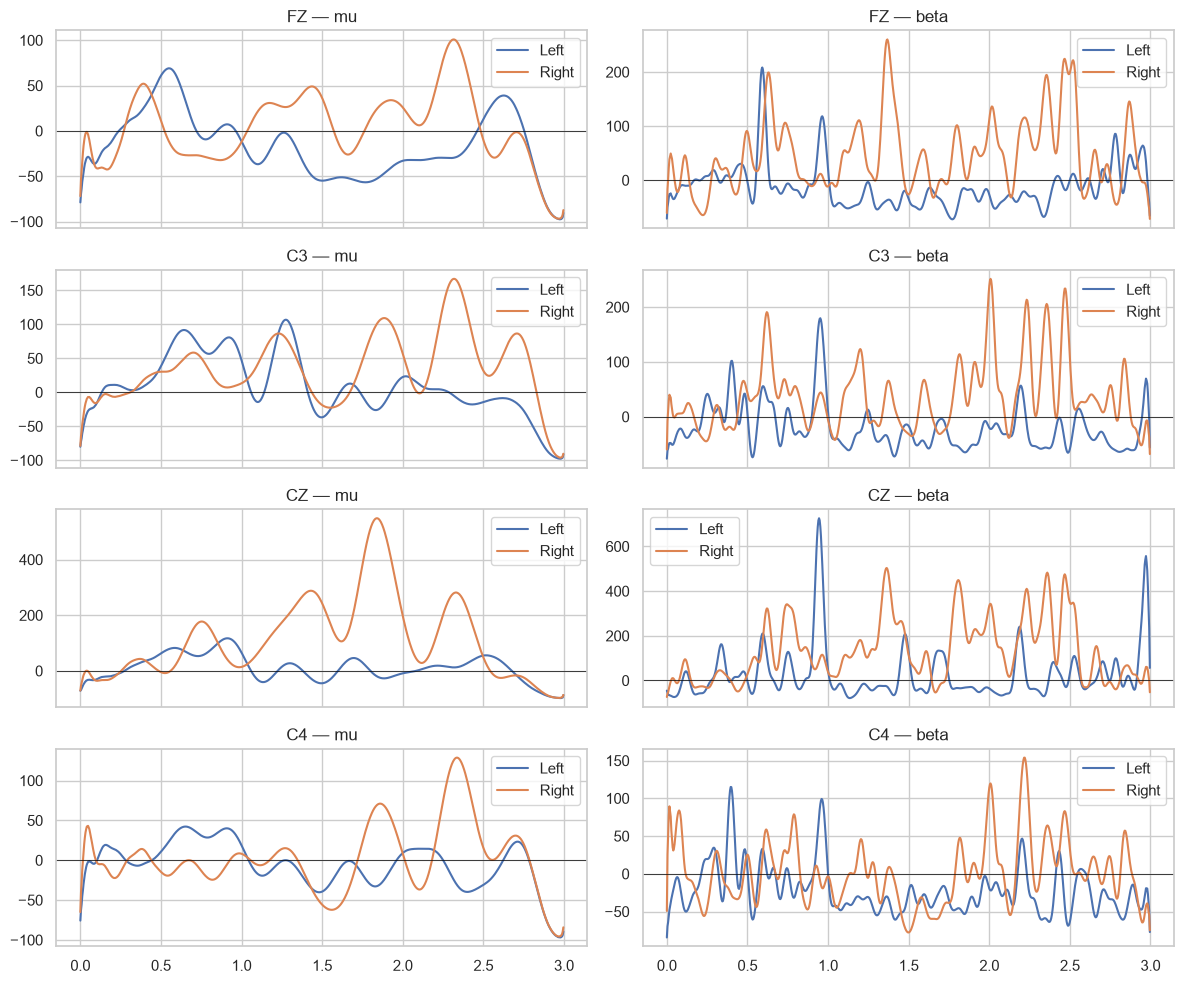

In [24]:
import numpy as np
import json
from scipy.signal import butter, sosfiltfilt, hilbert
import matplotlib.pyplot as plt

# تحميل البيانات لو مش موجودة بالذاكرة
epochs = np.load("outputs/processed_epochs.npy")
y = np.load("outputs/labels_encoded.npy").astype(int)
config = json.load(open("outputs/config.json"))
FS = config.get("fs", config.get("sfreq", 250.0))

X_raw = np.transpose(epochs, (0, 2, 1)).astype(np.float64)

# فلترة bandpass 8-30Hz (نفس اللي عملته سابقًا)
LOW, HIGH = 8.0, 30.0
sos = butter(4, [LOW/(FS/2), HIGH/(FS/2)], btype="bandpass", output="sos")
X_filtered = np.empty_like(X_raw)
for i in range(X_raw.shape[0]):
    for c in range(X_raw.shape[1]):
        X_filtered[i, c] = sosfiltfilt(sos, X_raw[i, c])

channels = ["FZ", "C3", "CZ", "C4"]
band_defs = {"mu": (8, 12), "beta": (13, 30)}

# ---- من هنا كود الـ ERD زي ما هو ----
def band_envelope(sig, fs, low, high):
    sos_b = butter(4, [low/(fs/2), high/(fs/2)], btype="bandpass", output="sos")
    filtered = sosfiltfilt(sos_b, sig)
    envelope = np.abs(hilbert(filtered))
    return envelope ** 2

t_axis = np.arange(X_filtered.shape[-1]) / FS

fig, axes = plt.subplots(len(channels), len(band_defs), figsize=(12, 10), sharex=True)

for ci, ch in enumerate(channels):
    for bi, (band_name, (low, high)) in enumerate(band_defs.items()):
        ax = axes[ci, bi]
        for cls, label in [(0, "Left"), (1, "Right")]:
            trials = X_filtered[y == cls, ci, :]
            powers = np.array([band_envelope(tr, FS, low, high) for tr in trials])
            mean_power = powers.mean(axis=0)
            baseline = mean_power[t_axis < 0.5].mean()
            erd_percent = 100 * (mean_power - baseline) / baseline
            ax.plot(t_axis, erd_percent, label=label)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_title(f"{ch} — {band_name}")
        ax.legend()

plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import ttest_ind
import numpy as np

def band_power(sig, fs, low, high):
    sos = butter(4, [low/(fs/2), high/(fs/2)], btype="bandpass", output="sos")
    filtered = sosfiltfilt(sos, sig)
    return np.mean(filtered ** 2)  # متوسط القدرة على كامل الـ epoch

def permutation_test(a, b, n_perm=5000, seed=42):
    rng = np.random.default_rng(seed)
    observed_diff = np.mean(a) - np.mean(b)
    combined = np.concatenate([a, b])
    n_a = len(a)
    diffs = np.empty(n_perm)
    for i in range(n_perm):
        rng.shuffle(combined)
        diffs[i] = np.mean(combined[:n_a]) - np.mean(combined[n_a:])
    p_value = np.mean(np.abs(diffs) >= np.abs(observed_diff))
    return observed_diff, p_value

results = []
for ci, ch in enumerate(channels):
    for band_name, (low, high) in band_defs.items():
        powers = np.array([band_power(tr, FS, low, high) for tr in X_filtered[:, ci, :]])
        left_powers = powers[y == 0]
        right_powers = powers[y == 1]

        # t-test التقليدي (سريع، للمقارنة)
        t_stat, p_ttest = ttest_ind(left_powers, right_powers)

        # permutation test (أدق)
        diff, p_perm = permutation_test(left_powers, right_powers)

        results.append({
            "channel": ch,
            "band": band_name,
            "mean_diff_left_minus_right": diff,
            "p_value_ttest": p_ttest,
            "p_value_permutation": p_perm,
            "significant_0.05": p_perm < 0.05
        })

results_df = pd.DataFrame(results)
print(results_df)

  channel  band  mean_diff_left_minus_right  p_value_ttest  \
0      FZ    mu                 -149.840406       0.019270   
1      FZ  beta                 -207.731548       0.039353   
2      C3    mu                  -37.987484       0.502731   
3      C3  beta                   36.267046       0.655641   
4      CZ    mu                 -165.590910       0.078084   
5      CZ  beta                  -44.927429       0.675898   
6      C4    mu                 -176.034830       0.075036   
7      C4  beta                 -117.958287       0.305031   

   p_value_permutation  significant_0.05  
0               0.0112              True  
1               0.0374              True  
2               0.5222             False  
3               0.6586             False  
4               0.0720             False  
5               0.6828             False  
6               0.0764             False  
7               0.3036             False  


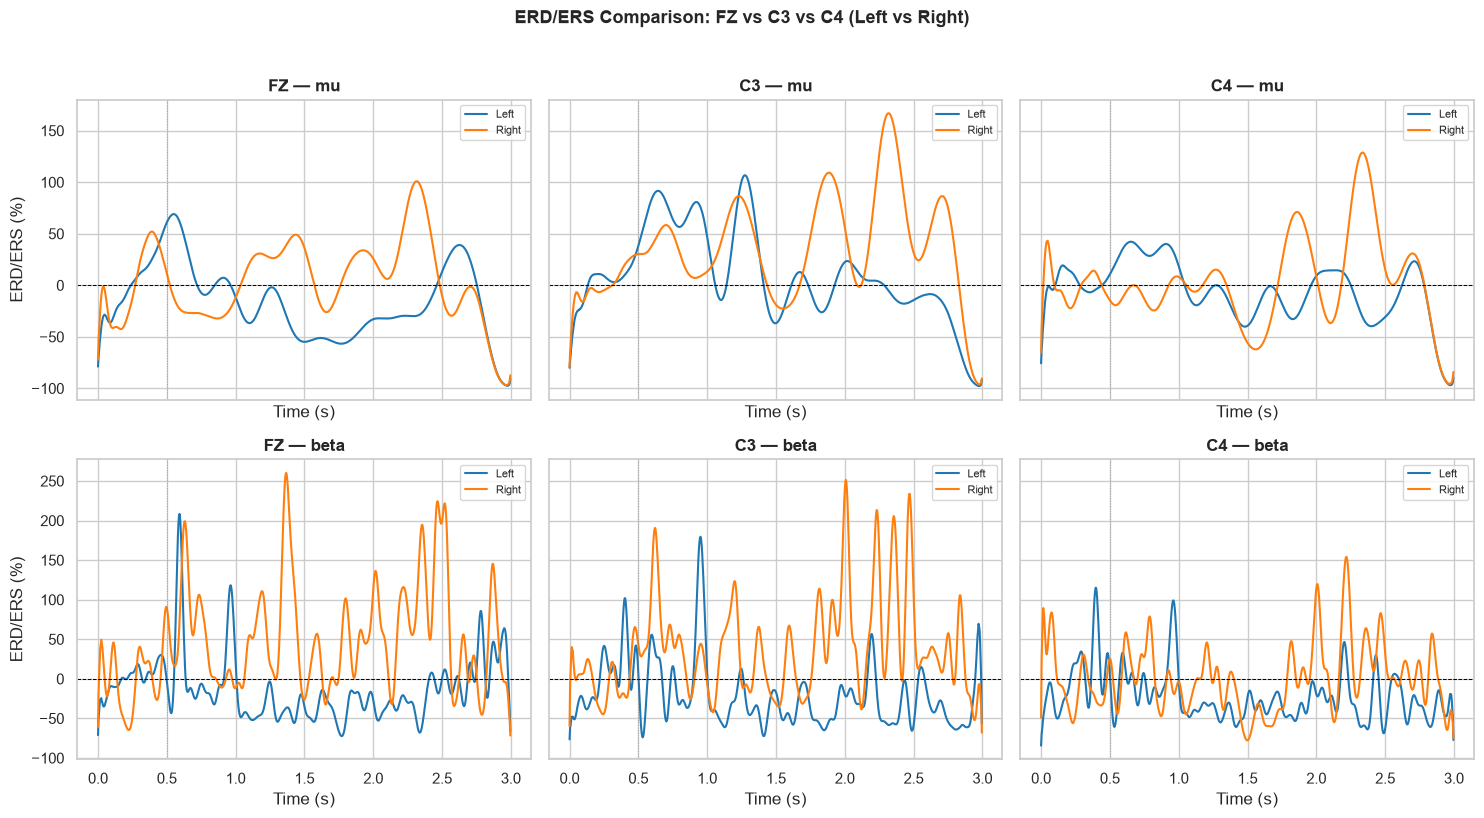

In [26]:
# ============ تأكد إن setup اشتغل قبل هالخلية ============
from scipy.signal import hilbert
import numpy as np
import matplotlib.pyplot as plt

def band_envelope_power(sig, fs, low, high):
    sos_b = butter(4, [low/(fs/2), high/(fs/2)], btype="bandpass", output="sos")
    filtered = sosfiltfilt(sos_b, sig)
    envelope = np.abs(hilbert(filtered))
    return envelope ** 2

t_axis = np.arange(X_filtered.shape[-1]) / FS

# نركز بس على القنوات الثلاث المهمة حسب نتائج الاختبار الإحصائي
focus_channels = ["FZ", "C3", "C4"]
focus_idx = [channels.index(ch) for ch in focus_channels]

fig, axes = plt.subplots(len(band_defs), len(focus_channels), figsize=(15, 8), sharex=True, sharey='row')

for bi, (band_name, (low, high)) in enumerate(band_defs.items()):
    for ci_local, (ch, ci) in enumerate(zip(focus_channels, focus_idx)):
        ax = axes[bi, ci_local]
        for cls, label, color in [(0, "Left", "tab:blue"), (1, "Right", "tab:orange")]:
            trials = X_filtered[y == cls, ci, :]
            powers = np.array([band_envelope_power(tr, FS, low, high) for tr in trials])
            mean_power = powers.mean(axis=0)

            # baseline من أول 0.5 ثانية
            baseline = mean_power[t_axis < 0.5].mean()
            erd_percent = 100 * (mean_power - baseline) / baseline

            ax.plot(t_axis, erd_percent, label=label, color=color, linewidth=1.5)

        ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
        ax.axvline(0.5, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)  # نهاية الـ baseline
        ax.set_title(f"{ch} — {band_name}", fontweight="bold")
        ax.set_xlabel("Time (s)")
        if ci_local == 0:
            ax.set_ylabel("ERD/ERS (%)")
        ax.legend(fontsize=8)

plt.suptitle("ERD/ERS Comparison: FZ vs C3 vs C4 (Left vs Right)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/erd_ers_focus_channels.png", dpi=300, bbox_inches="tight")
plt.show()

## 11. Machine Learning Baseline — CSP + SVM

A classical baseline model (CSP features + SVM, tuned with grid search) trained on the same epoched data, for comparison against the deep-learning pipeline that follows.

In [27]:
!pip install mne

In [28]:
import mne
print("mne version:", mne.__version__)

from mne.decoding import CSP
print("CSP imported successfully")

mne version: 1.12.1
CSP imported successfully


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Train class balance:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test class balance:", dict(zip(*np.unique(y_test, return_counts=True))))

Train shape: (1616, 4, 750) | Test shape: (405, 4, 750)
Train class balance: {np.int64(0): np.int64(808), np.int64(1): np.int64(808)}
Test class balance: {np.int64(0): np.int64(203), np.int64(1): np.int64(202)}


In [30]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pipeline = Pipeline([
    ("csp", CSP(n_components=4, reg=None, log=True)),
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42)),
])

param_grid = {
    "csp__n_components": [2, 4],   # أقصى حاجة ممكنة بـ 4 channels هي 4 (يعني كل الـ channels)
    "svm__C": [0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="balanced_accuracy", n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Best CV balanced accuracy:", grid.best_score_)
print("Best params:", grid.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 4 dim * 4.2e+16  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


c:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best CV balanced accuracy: 0.5166666666666667
Best params: {'csp__n_components': 4, 'svm__C': 100, 'svm__kernel': 'rbf'}


In [31]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    confusion_matrix, roc_auc_score, classification_report
)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix (rows=true, cols=pred), order=[Left(0), Right(1)]:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Left", "Right"]))

Accuracy: 0.49876543209876545
Balanced Accuracy: 0.49859776618055895
F1 Score: 0.46153846153846156
ROC AUC: 0.5

Confusion Matrix (rows=true, cols=pred), order=[Left(0), Right(1)]:
[[115  88]
 [115  87]]

Classification Report:
              precision    recall  f1-score   support

        Left       0.50      0.57      0.53       203
       Right       0.50      0.43      0.46       202

    accuracy                           0.50       405
   macro avg       0.50      0.50      0.50       405
weighted avg       0.50      0.50      0.50       405



In [32]:
import joblib
import json
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

# حفظ الموديل
joblib.dump(best_model, "outputs/baseline_csp_svm_mne_model.joblib")

# حفظ النتائج في ملف JSON
results = {
    "method": "CSP (mne) + SVM",
    "cv_balanced_accuracy": grid.best_score_,
    "best_params": grid.best_params_,
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "test_f1": f1_score(y_test, y_pred),
    "test_roc_auc": roc_auc_score(y_test, y_proba),
    "n_train": len(y_train),
    "n_test": len(y_test),
    "conclusion": "Model performs at chance level (AUC=0.5). Likely cause: unverified label-to-file mapping flagged in Data Processing notebook (240 extra rows in labels.csv). PSD analysis also shows no visible mu/beta difference between classes."
}

with open("outputs/baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved model and results to outputs/")

Saved model and results to outputs/


In [33]:
class BandpassFilter(BaseEstimator, TransformerMixin):
    def __init__(self, fs=250.0, low=8.0, high=30.0, order=4):
        self.fs = fs
        self.low = low
        self.high = high
        self.order = order

    def fit(self, X, y=None):
        self.sos_ = butter(self.order, [self.low / (self.fs / 2), self.high / (self.fs / 2)],
                            btype="bandpass", output="sos")
        return self

    def transform(self, X):
        out = np.empty_like(X)
        for i in range(X.shape[0]):
            for c in range(X.shape[1]):
                out[i, c] = sosfiltfilt(self.sos_, X[i, c])
        return out

In [34]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)
# ملحوظة: نفس random_state ونفس النسب، يبقى نفس الـ trials بالظبط اللي كانت في التقسيم الأول

full_pipeline = Pipeline([
    ("bandpass", BandpassFilter(fs=FS, low=8.0, high=30.0)),
    ("csp", CSP(n_components=4, reg=None, log=True)),
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42)),
])

param_grid = {
    "csp__n_components": [2, 4],
    "svm__C": [0.1, 1, 10, 100],
    "svm__kernel": ["linear", "rbf"],
}

grid_full = GridSearchCV(full_pipeline, param_grid, cv=cv, scoring="balanced_accuracy", n_jobs=-1, verbose=1)
grid_full.fit(X_train_raw, y_train)

print("Best CV balanced accuracy (full self-contained pipeline):", grid_full.best_score_)
print("Best params:", grid_full.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Computing rank from data with rank=None
    Using tolerance 38 (2.2e-16 eps * 4 dim * 4.2e+16  max singular value)
    Estimated rank (data): 4
    data: rank 4 computed from 4 data channels with 0 projectors
Reducing data rank from 4 -> 4
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


c:\Users\VICTUS\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best CV balanced accuracy (full self-contained pipeline): 0.5166666666666667
Best params: {'csp__n_components': 4, 'svm__C': 100, 'svm__kernel': 'rbf'}


In [35]:
best_full_model = grid_full.best_estimator_

# تقييم عادي على test set
y_pred_full = best_full_model.predict(X_test_raw)
y_proba_full = best_full_model.predict_proba(X_test_raw)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_full))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_full))
print("F1:", f1_score(y_test, y_pred_full))
print("ROC AUC:", roc_auc_score(y_test, y_proba_full))

label_names = {0: "Left", 1: "Right"}

sample_idx = 0  # أول trial في الـ test set، كمثال بس
single_trial = X_test_raw[sample_idx:sample_idx+1]   # لازم يفضل 3D shape: (1, channels, time)
true_label = y_test[sample_idx]

pred_class = best_full_model.predict(single_trial)[0]
pred_proba = best_full_model.predict_proba(single_trial)[0]

print(f"\n--- Single Trial Prediction Example ---")
print(f"True label     : {label_names[true_label]}")
print(f"Predicted label: {label_names[pred_class]}")
print(f"Confidence     : Left={pred_proba[0]*100:.1f}%  Right={pred_proba[1]*100:.1f}%")

Accuracy: 0.49876543209876545
Balanced Accuracy: 0.49859776618055895
F1: 0.46153846153846156
ROC AUC: 0.5

--- Single Trial Prediction Example ---
True label     : Left
Predicted label: Left
Confidence     : Left=50.0%  Right=50.0%


In [36]:
import joblib
import json
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

# حفظ الموديل الكامل (فلتر + CSP + SVM في حاجة واحدة)
joblib.dump(best_full_model, "outputs/baseline_csp_svm_final_model.joblib")

results_final = {
    "method": "Bandpass(8-30Hz) + CSP (mne) + SVM  [fully self-contained pipeline]",
    "cv_balanced_accuracy": grid_full.best_score_,
    "best_params": grid_full.best_params_,
    "test_accuracy": accuracy_score(y_test, y_pred_full),
    "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_full),
    "test_f1": f1_score(y_test, y_pred_full),
    "test_roc_auc": roc_auc_score(y_test, y_proba_full),
    "n_train": len(y_train),
    "n_test": len(y_test),
    "note_for_deployment": "This model expects RAW (unfiltered) epoched trials as input, shape (n_trials, n_channels, n_time). Bandpass filtering (8-30Hz) is applied automatically inside the pipeline — do NOT pre-filter before calling .predict().",
    "conclusion": "Model performs at chance level (AUC=0.5, single-trial confidence exactly 50/50). Likely cause: unverified label-to-file mapping flagged in Data Processing notebook (240 extra rows in labels.csv)."
}

with open("outputs/baseline_results_final.json", "w") as f:
    json.dump(results_final, f, indent=2)

print("Saved final self-contained model and results.")

Saved final self-contained model and results.


# 🧠 EEG Motor Imagery Classification — EEGNet End-to-End Scientific Pipeline

**Task:** Binary classification of Left-Hand vs Right-Hand motor imagery from raw 4-channel EEG (FZ, C3, CZ, C4 @ ~250 Hz).

**Ground rules for this notebook (non-negotiable):**
- Everything is derived **from the raw CSV files**. No previous notebook, model, metric, or conclusion is trusted or reused.
- The test set is touched **exactly once**, at the very end, after every preprocessing/model decision is frozen.
- No fabricated or "adjusted" metrics. If the signal is weak, the notebook says so.
- All reported numbers in the final audit are **computed variables**, never hardcoded literals.

**Priority order:** DATA INTEGRITY > NO LEAKAGE > SCIENTIFIC VALIDITY > REPRODUCIBILITY > MODEL PERFORMANCE.

### Sections
1. Configuration
2. Imports
3. Raw Data Discovery
4. Raw Data Audit (Phase 1)
5. Duplicate / Label-Conflict Audit (Phase 2)
6. Run / Group Identification (Phase 3)
7. EEG Preprocessing (Phase 4)
8. Dataset Quality Checks (Phase 5)
9. Group-Aware Split (Phase 6)
10. Classical Baseline (Phase 7)
11. EEGNet Definition (Phase 8)
12. Training (Phase 9)
13. Small Ablation (Phase 10, optional)
14. Final Test (Phase 11)
15. Scientific Diagnosis (Phase 12)
16. Final Automated Audit + Artifact Export (Phase 13-15)


In [37]:
import glob
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, iirnotch, sosfiltfilt, tf2sos

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 3.5)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ============================================================
# تم تحديد المسار طبقًا لجهازك والمجلدات الحالية
DATA_ROOT = Path("DATA_ROOT")
# ============================================================

def _find_mi_csv_dir(root: Path) -> Path:
    matches = [p for p in root.rglob("MI CSV") if p.is_dir()]
    if not matches:
        raise FileNotFoundError(
            f"Could not find an 'MI CSV' folder anywhere under {root.resolve()}. "
            "Check DATA_ROOT above points at the right place."
        )
    return matches[0]

RAW_DIR = _find_mi_csv_dir(DATA_ROOT)

CONFIG = {
    "raw_dir": str(RAW_DIR),
    "labels_csv": str(DATA_ROOT / "labels.csv"),
    "channels": ["FZ", "C3", "CZ", "C4"],
    "fs": 250.0,                    # verified in Step 1 (median estimated fs across all trials)
    "bandpass_hz": [0.5, 40.0],     # Table 1, step 2
    "bandpass_order": 4,
    "notch_freq_hz": 50.0,          # Table 1, step 3 (mains hum)
    "notch_q": 30.0,
    "artifact_reject_k_mad": 5.0,   # Table 1, step 4 — trial-level peak-to-peak, robust (median + k*MAD) threshold
    "apply_car": True,              # Table 1, step 5
    "epoch_window_s": [0.5, 3.5],   # Table 1, step 6 — ASSUMPTION
    "baseline_window_s": [0.0, 0.5],# Table 1, step 7
    "normalize_default_on": False,  # Table 1, step 8
    "random_seed": 42,
    "output_dir": "outputs",
}

Path(CONFIG["output_dir"]).mkdir(exist_ok=True)
CONFIG

{'raw_dir': 'DATA_ROOT\\MI-20260822T165808Z-1-001\\MI\\MI CSV',
 'labels_csv': 'DATA_ROOT\\labels.csv',
 'channels': ['FZ', 'C3', 'CZ', 'C4'],
 'fs': 250.0,
 'bandpass_hz': [0.5, 40.0],
 'bandpass_order': 4,
 'notch_freq_hz': 50.0,
 'notch_q': 30.0,
 'artifact_reject_k_mad': 5.0,
 'apply_car': True,
 'epoch_window_s': [0.5, 3.5],
 'baseline_window_s': [0.0, 0.5],
 'normalize_default_on': False,
 'random_seed': 42,
 'output_dir': 'outputs'}

In [1]:
!pip install torch

In [1]:
import os
import torch

print("تم تحميل PyTorch بنجاح! النسخة المثبتة:", torch.__version__)
print("الجهاز المستعمل:", "CUDA Available" if torch.cuda.is_available() else "CPU")

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\VICTUS\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [3]:
%pip uninstall torch torchvision torchaudio -y
%pip install torch --index-url https://download.pytorch.org/whl/cpu

Found existing installation: torch 2.13.0
Uninstalling torch-2.13.0:
  Successfully uninstalled torch-2.13.0
Note: you may need to restart the kernel to use updated packages.


Looking in indexes: https://download.pytorch.org/whl/cpu
  Obtaining dependency information for torch from https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (39 kB)
Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl (121.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
!pip uninstall -y torch torchvision torchaudio numpy

!pip install "numpy<2.0.0" 

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Found existing installation: torch 2.13.0+cpu
Uninstalling torch-2.13.0+cpu:
  Successfully uninstalled torch-2.13.0+cpu
Found existing installation: torchaudio 2.11.0+cpu
Uninstalling torchaudio-2.11.0+cpu:
  Successfully uninstalled torchaudio-2.11.0+cpu
Found existing installation: numpy 2.4.6
Uninstalling numpy-2.4.6:
  Successfully uninstalled numpy-2.4.6


  Obtaining dependency information for numpy<2.0.0 from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.


Looking in indexes: https://download.pytorch.org/whl/cpu
  Obtaining dependency information for torch from https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (39 kB)
  Obtaining dependency information for torchvision from https://download-r2.pytorch.org/whl/cpu/torchvision-0.28.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.28.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (5.7 kB)
  Obtaining dependency information for torchaudio from https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata
  Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.13.0%2Bcpu-cp311-cp311-win_amd64.whl (121.9 MB)
Using cached htt

In [3]:
import os
import sys

# إضافة مسار مكتبات DLL لبيئة أنكوندا يدويًا
anaconda_path = r"C:\Users\VICTUS\anaconda3"
os.add_dll_directory(os.path.join(anaconda_path, 'Library', 'bin'))

# منع تعارض مكتبات Intel OMP
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
print("تم التحميل بنجاح! النسخة:", torch.__version__)
import torch.optim as optim


OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\VICTUS\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [5]:
# =============================================================
# CELL 1: Phase 0 — Project Inventory & Global Configuration
# =============================================================
import os
import sys
import glob
import time
import json
import hashlib
import random
import warnings
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, confusion_matrix
)


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning)

# -------------------------------------------------------------
# Global Reproducibility Configuration
# -------------------------------------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CONFIG = {
    'fs': 250.0,                      # nominal sampling rate; verified forensically in Phase 1
    'channels': ['FZ', 'C3', 'CZ', 'C4'],
    'filter_low_hz': 8.0,
    'filter_high_hz': 30.0,
    'filter_order': 4,
    'epoch_window_sec': [0.5, 3.5],   # relative to trial/cue start
    'n_samples': 750,                 # expected epoch length at 250 Hz (0.5s-3.5s => 3.0s window)
    'n_classes': 2,
    'batch_size': 32,
    'learning_rate': 1e-3,
    'weight_decay': 1e-4,
    'max_epochs': 60,
    'early_stopping_patience': 12,
    'test_split_ratio': 0.15,
    'val_split_ratio': 0.15,
    'seed': RANDOM_SEED,
    'device': str(DEVICE),
    # Fallback assumption ONLY used if no explicit run/session column is found
    # in the raw data or an accompanying metadata file (see Phase 3).
    'fallback_trials_per_run': 9,
}

# -------------------------------------------------------------
# Locate the working directory that actually contains the raw data.
# Search order: current dir -> ./EEG -> ./data -> notebook's own dir.
# -------------------------------------------------------------
def _looks_like_data_dir(d):
    return len(glob.glob(os.path.join(d, 'cellula_MI_data_*.csv'))) > 0

candidate_dirs = [os.getcwd(),
                   os.path.join(os.getcwd(), 'EEG'),
                   os.path.join(os.getcwd(), 'data'),
                   os.path.dirname(os.path.abspath('__file__'))]

eeg_dir = None
for d in candidate_dirs:
    if os.path.isdir(d) and _looks_like_data_dir(d):
        eeg_dir = d
        break
if eeg_dir is None:
    eeg_dir = os.getcwd()  # last resort; Phase 1 will fail loudly if data is absent

# Project Inventory
raw_files_found = glob.glob(os.path.join(eeg_dir, 'cellula_MI_data_*.csv'))
notebooks_found = glob.glob(os.path.join(eeg_dir, '*.ipynb'))
labels_csv_path = os.path.join(eeg_dir, 'labels.csv')

print("=" * 60)
print("PHASE 0: PROJECT INVENTORY")
print("=" * 60)
print(f"  - Execution Target Directory : {eeg_dir}")
print(f"  - Raw EEG Files Found        : {len(raw_files_found)}")
print(f"  - Labels File Present        : {os.path.exists(labels_csv_path)}")
print(f"  - Existing Notebooks Nearby  : {len(notebooks_found)} ({[os.path.basename(n) for n in notebooks_found]})")
print(f"  - Compute Device             : {DEVICE}")
print(f"  - Master Random Seed         : {RANDOM_SEED}")
print("=" * 60)

if len(raw_files_found) == 0:
    raise FileNotFoundError(
        "No 'cellula_MI_data_*.csv' files were found under any candidate directory: "
        f"{candidate_dirs}. Place the raw data next to this notebook (or in an 'EEG'/'data' "
        "subfolder) before continuing."
    )


OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\VICTUS\anaconda3\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [6]:
# =============================================================
# CELL 2: Phase 1 — Raw Data Forensic Audit
# =============================================================
def extract_file_id(fn):
    base = os.path.splitext(os.path.basename(fn))[0]
    return int(base.split('_')[-1])

raw_csv_files_unsorted = raw_files_found
raw_csv_files = sorted(raw_csv_files_unsorted, key=extract_file_id)

file_ids_all = [extract_file_id(f) for f in raw_csv_files]

# 1 & 2 — count + missing IDs (based on the observed min..max range, not an assumed total)
n_files_found = len(raw_csv_files)
min_id, max_id = min(file_ids_all), max(file_ids_all)
expected_id_range = set(range(min_id, max_id + 1))
missing_ids = sorted(expected_id_range - set(file_ids_all))

# 3 — duplicate filenames (by file id, since ids should be unique)
from collections import Counter
id_counts = Counter(file_ids_all)
duplicate_filename_ids = sorted([fid for fid, c in id_counts.items() if c > 1])

readable_files, corrupted_files = [], []
row_counts, col_counts = [], []
channel_name_sets = []
has_time_col, has_label_col = [], []
nan_count_total, inf_count_total = 0, 0
flat_channel_trials = 0
constant_column_trials = 0
raw_arrays_list = []
raw_time_list = []
dt_all = []

for fpath in raw_csv_files:
    try:
        df_trial = pd.read_csv(fpath)
        readable_files.append(fpath)
    except Exception as e:
        corrupted_files.append((fpath, str(e)))
        raw_arrays_list.append(None)
        raw_time_list.append(None)
        continue

    row_counts.append(df_trial.shape[0])
    col_counts.append(df_trial.shape[1])
    channel_name_sets.append(tuple(df_trial.columns))

    time_col = next((c for c in df_trial.columns if c.strip().lower() in ('time', 'timestamp', 't')), None)
    has_time_col.append(time_col is not None)

    label_col = next((c for c in df_trial.columns if c.strip().lower() in ('label', 'class', 'target')), None)
    has_label_col.append(label_col is not None)

    missing_channels = [ch for ch in CONFIG['channels'] if ch not in df_trial.columns]
    if missing_channels:
        raw_arrays_list.append(None)
        raw_time_list.append(df_trial[time_col].values if time_col else None)
        continue

    vals = df_trial[CONFIG['channels']].values.astype(np.float64)
    nan_count_total += int(np.isnan(vals).sum())
    inf_count_total += int(np.isinf(vals).sum())

    per_channel_var = np.nanvar(vals, axis=0)
    if (per_channel_var < 1e-9).any():
        flat_channel_trials += 1
    # a fully-constant single column anywhere (incl. non-EEG columns)
    if (df_trial.nunique(dropna=False) <= 1).any():
        constant_column_trials += 1

    if time_col is not None:
        t = df_trial[time_col].values.astype(np.float64)
        dt = np.diff(t)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        if len(dt) > 0:
            dt_all.append(dt)
        raw_time_list.append(t)
    else:
        raw_time_list.append(None)

    raw_arrays_list.append(vals)

# 5/6/7 — row/col/channel structure consistency
unique_row_counts = sorted(set(row_counts)) if row_counts else []
unique_col_counts = sorted(set(col_counts)) if col_counts else []
unique_channel_sets = sorted(set(channel_name_sets), key=lambda s: (len(s), s)) if channel_name_sets else []

# 10 — sampling rate: robust estimate from ALL trials' dt, mean AND median reported
if dt_all:
    dt_concat = np.concatenate(dt_all)
    dt_mean = float(np.mean(dt_concat))
    dt_median = float(np.median(dt_concat))
    dt_std = float(np.std(dt_concat))
    fs_from_mean = 1.0 / dt_mean if dt_mean > 0 else float('nan')
    fs_from_median = 1.0 / dt_median if dt_median > 0 else float('nan')
else:
    dt_mean = dt_median = dt_std = float('nan')
    fs_from_mean = fs_from_median = float('nan')

# Decide the nominal sampling rate from the complete evidence rather than blindly
# trusting either statistic: if mean and median disagree by more than ~5%, jitter is
# present and we fall back to the value closest to the CONFIG-declared nominal rate
# (250 Hz), which is the manufacturer/protocol-declared rate for this hardware.
candidates = [c for c in (fs_from_mean, fs_from_median) if np.isfinite(c)]
if not candidates:
    nominal_fs = CONFIG['fs']
    fs_decision_note = "No usable timestamp column found; falling back to CONFIG nominal fs."
elif abs(fs_from_mean - fs_from_median) / max(fs_from_mean, fs_from_median) > 0.05:
    nominal_fs = min(candidates, key=lambda c: abs(c - CONFIG['fs']))
    fs_decision_note = (f"mean-based ({fs_from_mean:.2f} Hz) and median-based ({fs_from_median:.2f} Hz) "
                         f"estimates disagree by >5% (timestamp jitter) -> chose the estimate closest to "
                         f"the declared nominal rate ({CONFIG['fs']} Hz).")
else:
    nominal_fs = fs_from_mean
    fs_decision_note = "mean- and median-based estimates agree within 5%; using mean-based estimate."

CONFIG['fs'] = float(nominal_fs) if np.isfinite(nominal_fs) else CONFIG['fs']

# 15/16 — labels: only checkable once we load labels.csv or an in-file label column (Phase 1b below)
print("=" * 60)
print("PHASE 1: RAW DATA FORENSIC AUDIT")
print("=" * 60)
print(f"  Files found (by id range {min_id}-{max_id}) : {n_files_found}")
print(f"  Missing file IDs in range        : {len(missing_ids)} {missing_ids[:20]}{'...' if len(missing_ids) > 20 else ''}")
print(f"  Duplicate filename IDs            : {len(duplicate_filename_ids)} {duplicate_filename_ids[:20]}")
print(f"  Readable files                    : {len(readable_files)}")
print(f"  Corrupted / unreadable files      : {len(corrupted_files)}")
print(f"  Row counts observed               : {unique_row_counts}")
print(f"  Column counts observed            : {unique_col_counts}")
print(f"  Distinct column-name sets observed: {len(unique_channel_sets)}")
for s in unique_channel_sets[:5]:
    print(f"      - {s}")
print(f"  Trials with a recognizable time col: {sum(has_time_col)}/{len(has_time_col)}")
print(f"  Trials with an in-file label col   : {sum(has_label_col)}/{len(has_label_col)}")
print(f"  NaN count (EEG channels)           : {nan_count_total}")
print(f"  Inf count (EEG channels)           : {inf_count_total}")
print(f"  Trials with a flat EEG channel     : {flat_channel_trials}")
print(f"  Trials with any constant column    : {constant_column_trials}")
print("-" * 60)
print(f"  dt mean / median / std (s)         : {dt_mean:.6f} / {dt_median:.6f} / {dt_std:.6f}")
print(f"  Estimated fs (from mean dt)        : {fs_from_mean:.3f} Hz")
print(f"  Estimated fs (from median dt)      : {fs_from_median:.3f} Hz")
print(f"  Decision                          : {fs_decision_note}")
print(f"  NOMINAL SAMPLING RATE ADOPTED      : {CONFIG['fs']:.3f} Hz")
print("=" * 60)

assert len(corrupted_files) == 0, f"{len(corrupted_files)} raw files failed to parse: {corrupted_files[:5]}"
assert nan_count_total == 0, f"NaNs present in raw EEG channels: {nan_count_total}"
assert inf_count_total == 0, f"Infs present in raw EEG channels: {inf_count_total}"
assert len(unique_col_counts) == 1 or len(unique_channel_sets) == 1, (
    "Raw files do not share a consistent column structure -- inspect unique_channel_sets before proceeding."
)


NameError: name 'raw_files_found' is not defined

In [ ]:
# =============================================================
# CELL 3: Phase 1b — Label Loading & Traceability
# =============================================================
# Labels are expected either as a shared 'labels.csv' (one row per trial, in file-id
# order) or as an in-file label column. We prefer labels.csv if present, since that
# matches the documented data layout; otherwise we fall back to the in-file column.
label_source = None
labels_aligned = None

if os.path.exists(labels_csv_path):
    df_labels_raw = pd.read_csv(labels_csv_path)
    label_col_name = next((c for c in df_labels_raw.columns if c.strip().lower() in ('label', 'class', 'target')), None)
    assert label_col_name is not None, f"Could not find a label column in {labels_csv_path} (columns: {list(df_labels_raw.columns)})"
    assert len(df_labels_raw) >= len(raw_csv_files), (
        f"labels.csv has {len(df_labels_raw)} rows but {len(raw_csv_files)} raw trial files were found."
    )
    labels_aligned = df_labels_raw[label_col_name].astype(str).str.strip().values[:len(raw_csv_files)]
    label_source = labels_csv_path
elif any(has_label_col):
    # fall back: read the label straight out of each trial file (first value, since it
    # should be constant across the whole trial)
    labels_list = []
    for fpath in raw_csv_files:
        df_trial = pd.read_csv(fpath)
        lbl_col = next((c for c in df_trial.columns if c.strip().lower() in ('label', 'class', 'target')), None)
        labels_list.append(str(df_trial[lbl_col].iloc[0]).strip())
    labels_aligned = np.array(labels_list)
    label_source = "in-file 'label' column"
else:
    raise FileNotFoundError(
        "No label source found: neither a 'labels.csv' file next to the raw data, "
        "nor a recognizable in-file label column."
    )

unique_label_values = sorted(pd.unique(labels_aligned))
# Map known left/right variants to 0/1; anything else is 'unknown'
LEFT_ALIASES = {'left', 'left hand', 'l', '0'}
RIGHT_ALIASES = {'right', 'right hand', 'r', '1'}

def map_label(v):
    lv = str(v).strip().lower()
    if lv in LEFT_ALIASES:
        return 0
    if lv in RIGHT_ALIASES:
        return 1
    return -1

labels_mapped = np.array([map_label(v) for v in labels_aligned])
unknown_label_mask = labels_mapped == -1
n_unknown_labels = int(unknown_label_mask.sum())

left_count_raw = int((labels_mapped == 0).sum())
right_count_raw = int((labels_mapped == 1).sum())

print("=" * 60)
print("PHASE 1b: LABEL TRACEABILITY")
print("=" * 60)
print(f"  Label source                : {label_source}")
print(f"  Distinct raw label values    : {list(unique_label_values)}")
print(f"  Total labels aligned         : {len(labels_aligned)}")
print(f"  Mapped Left  (0) count       : {left_count_raw} ({left_count_raw/len(labels_aligned)*100:.2f}%)")
print(f"  Mapped Right (1) count       : {right_count_raw} ({right_count_raw/len(labels_aligned)*100:.2f}%)")
print(f"  Unknown / unmapped labels    : {n_unknown_labels}")
print("=" * 60)

if n_unknown_labels > 0:
    bad_examples = list(pd.unique(np.array(labels_aligned)[unknown_label_mask]))[:10]
    print(f"  WARNING: unrecognized label values (examples): {bad_examples}")
    print("  -> these trials will be EXCLUDED from the ML dataset (Phase 2 report will confirm count).")


In [ ]:
# =============================================================
# CELL 4: Phase 2 — SHA-256 Duplicate & Label-Conflict Audit
# =============================================================
metadata_raw_list = []

for idx, fpath in enumerate(raw_csv_files):
    fid = file_ids_all[idx]
    vals = raw_arrays_list[idx]
    if vals is None:
        continue  # already failed structural checks above; excluded from ML entirely
    sig_hash = hashlib.sha256(np.ascontiguousarray(vals).tobytes()).hexdigest()
    lbl_int = int(labels_mapped[idx])

    metadata_raw_list.append({
        'raw_index': idx,
        'file_id': fid,
        'filename': os.path.basename(fpath),
        'label': lbl_int,
        'label_valid': lbl_int != -1,
        'sha256': sig_hash,
    })

raw_metadata_df = pd.DataFrame(metadata_raw_list)

# Exclude trials with unknown/invalid labels before duplicate analysis -- an ambiguous
# label is a data-quality problem independent of duplication.
invalid_label_ids = set(raw_metadata_df.loc[~raw_metadata_df['label_valid'], 'file_id'])
raw_metadata_valid = raw_metadata_df[raw_metadata_df['label_valid']].copy()

grouped_by_hash = raw_metadata_valid.groupby('sha256')
dup_groups_frame = grouped_by_hash.filter(lambda g: len(g) > 1)
dup_groups = dup_groups_frame.groupby('sha256') if len(dup_groups_frame) > 0 else []

conflicting_file_ids = []
redundant_file_ids = []
audit_records = []
n_dup_groups = 0
n_conflicting_groups = 0
n_consistent_groups = 0

if len(dup_groups_frame) > 0:
    for sha, group in grouped_by_hash:
        if len(group) <= 1:
            continue
        n_dup_groups += 1
        lbls = group['label'].unique()
        fids = group['file_id'].tolist()
        is_conflict = len(lbls) > 1

        if is_conflict:
            n_conflicting_groups += 1
            conflicting_file_ids.extend(fids)
            reason = 'Conflicting labels for bit-for-bit identical EEG signal'
        else:
            n_consistent_groups += 1
            redundant_file_ids.extend(fids[1:])  # keep first occurrence only
            reason = 'Exact duplicate EEG signal with consistent label'

        for _, row in group.iterrows():
            excluded = row['file_id'] in conflicting_file_ids or row['file_id'] in redundant_file_ids
            audit_records.append({
                'duplicate_group_hash': sha,
                'file_id': row['file_id'],
                'label': row['label'],
                'is_conflicting': is_conflict,
                'reason': reason,
                'action': 'EXCLUDE' if excluded else 'KEEP'
            })

audit_df = pd.DataFrame(audit_records)

exclude_set = set(conflicting_file_ids) | set(redundant_file_ids) | invalid_label_ids
clean_metadata_df = raw_metadata_valid[~raw_metadata_valid['file_id'].isin(exclude_set)].copy().reset_index(drop=True)

print("=" * 60)
print("PHASE 2: DUPLICATE & LABEL-CONFLICT AUDIT")
print("=" * 60)
print(f"  Trials excluded for invalid/unknown label : {len(invalid_label_ids)}")
print(f"  Total exact-duplicate signal groups        : {n_dup_groups}")
print(f"  Conflicting duplicate groups                : {n_conflicting_groups}")
print(f"  Conflicting trials removed                  : {len(conflicting_file_ids)}")
print(f"  Consistent duplicate groups                 : {n_consistent_groups}")
print(f"  Redundant trials removed (deduplicated)      : {len(redundant_file_ids)}")
print(f"  Final unique clean trial count               : {len(clean_metadata_df)}")
print("=" * 60)

assert clean_metadata_df['file_id'].is_unique, "Duplicate file_id survived cleaning -- logic error."
assert clean_metadata_df['sha256'].is_unique, "Duplicate signal fingerprint survived cleaning -- logic error."


In [ ]:
# =============================================================
# CELL 5: Phase 3 — Run / Session Group Identification
# =============================================================
# Preference order for determining group_id (a run/session that must never be split
# across train/val/test):
#   1) An explicit run/session column in labels.csv or the raw trial files.
#   2) A 'runs.csv' / 'sessions.csv' mapping file next to the data.
#   3) A documented fallback: fixed-size consecutive blocks of file_id
#      (CONFIG['fallback_trials_per_run']), clearly flagged as an ASSUMPTION.
run_col_candidates = ('run', 'run_id', 'session', 'session_id', 'block', 'block_id')

group_source = None
file_id_to_group = {}

# 1) look in labels.csv
if os.path.exists(labels_csv_path):
    df_labels_full = pd.read_csv(labels_csv_path)
    run_col = next((c for c in df_labels_full.columns if c.strip().lower() in run_col_candidates), None)
    if run_col is not None:
        ids_full = list(range(min_id, min_id + len(df_labels_full)))
        file_id_to_group = dict(zip(ids_full, df_labels_full[run_col].values))
        group_source = f"labels.csv column '{run_col}'"

# 2) look for a dedicated runs/sessions mapping file
if group_source is None:
    for cand_name in ('runs.csv', 'sessions.csv', 'groups.csv'):
        cand_path = os.path.join(eeg_dir, cand_name)
        if os.path.exists(cand_path):
            df_runs = pd.read_csv(cand_path)
            id_col = next((c for c in df_runs.columns if c.strip().lower() in ('file_id', 'trial_id', 'id')), None)
            run_col = next((c for c in df_runs.columns if c.strip().lower() in run_col_candidates), None)
            if id_col is not None and run_col is not None:
                file_id_to_group = dict(zip(df_runs[id_col], df_runs[run_col]))
                group_source = f"{cand_name} column '{run_col}'"
                break

# 3) fallback: fixed-size consecutive blocks (documented assumption -- verify against
#    the real acquisition protocol before trusting downstream conclusions).
if group_source is None:
    tpr = CONFIG['fallback_trials_per_run']
    file_id_to_group = {fid: (fid - min_id) // tpr for fid in range(min_id, max_id + 1)}
    group_source = f"FALLBACK ASSUMPTION: consecutive blocks of {tpr} trials (unverified against real protocol)"

clean_metadata_df['group_id'] = clean_metadata_df['file_id'].map(file_id_to_group)
assert clean_metadata_df['group_id'].isna().sum() == 0, "Some clean trials could not be assigned a group_id."

n_groups = clean_metadata_df['group_id'].nunique()
group_sizes = clean_metadata_df.groupby('group_id').size()

print("=" * 60)
print("PHASE 3: RUN / GROUP IDENTIFICATION")
print("=" * 60)
print(f"  Group source                : {group_source}")
print(f"  Distinct groups (runs)       : {n_groups}")
print(f"  Group size distribution      : min={group_sizes.min()}, median={group_sizes.median():.1f}, max={group_sizes.max()}")
print("=" * 60)
if 'FALLBACK ASSUMPTION' in group_source:
    print("  NOTE: no explicit run/session column was found in the raw data. Grouping used a")
    print("  fixed block-size fallback. If this does not match the true acquisition protocol,")
    print("  the group-disjoint split below is only as good as this assumption -- verify")
    print("  independently against the data-collection log before trusting cross-run claims.")
    print("=" * 60)


In [ ]:
# =============================================================
# CELL 6: Phase 4 — Scientific EEG Preprocessing
# =============================================================
# Verify all retained trials share one consistent raw sample length before epoching.
raw_lengths = {}
for _, row in clean_metadata_df.iterrows():
    idx = row['raw_index']
    raw_lengths[row['file_id']] = raw_arrays_list[idx].shape[0]

unique_raw_lengths = sorted(set(raw_lengths.values()))
assert len(unique_raw_lengths) == 1, f"Inconsistent raw trial lengths across clean trials: {unique_raw_lengths}"
raw_trial_len = unique_raw_lengths[0]

fs = CONFIG['fs']
s_idx = int(round(CONFIG['epoch_window_sec'][0] * fs))
e_idx = int(round(CONFIG['epoch_window_sec'][1] * fs))
expected_epoch_len = e_idx - s_idx

assert e_idx <= raw_trial_len, (
    f"Requested epoch window [{CONFIG['epoch_window_sec']}] needs samples up to index {e_idx}, "
    f"but raw trials only have {raw_trial_len} samples at fs={fs:.2f} Hz."
)

# 4th-order zero-phase Butterworth bandpass, 8-30 Hz (mu/beta sensorimotor rhythms)
sos_filter = butter(CONFIG['filter_order'],
                     [CONFIG['filter_low_hz'], CONFIG['filter_high_hz']],
                     btype='band', fs=fs, output='sos')

epochs_list = []
kept_file_ids = []
for _, row in clean_metadata_df.iterrows():
    idx = row['raw_index']
    raw_sig = raw_arrays_list[idx].T  # (channels, samples)
    filt_sig = sosfiltfilt(sos_filter, raw_sig, axis=-1)
    epoch = filt_sig[:, s_idx:e_idx]
    epoch = epoch - epoch.mean(axis=-1, keepdims=True)  # per-channel baseline/DC correction
    epochs_list.append(epoch.astype(np.float32))
    kept_file_ids.append(row['file_id'])

X_clean_unscaled = np.stack(epochs_list, axis=0)  # (N, 4, n_samples)
clean_metadata_df = clean_metadata_df.set_index('file_id').loc[kept_file_ids].reset_index()

y_clean = clean_metadata_df['label'].values.astype(np.int64)
groups_clean = clean_metadata_df['group_id'].values

print("=" * 60)
print("PHASE 4: EEG PREPROCESSING SUMMARY")
print("=" * 60)
print(f"  Channels used                : {CONFIG['channels']}")
print(f"  Sampling rate used            : {fs:.3f} Hz")
print(f"  Raw samples/trial (verified)  : {raw_trial_len}")
print(f"  Bandpass filter               : {CONFIG['filter_order']}th-order zero-phase Butterworth, "
      f"{CONFIG['filter_low_hz']}-{CONFIG['filter_high_hz']} Hz")
print(f"  Epoch window (s)              : {CONFIG['epoch_window_sec']} -> samples [{s_idx}:{e_idx}]")
print(f"  Final epoch tensor shape      : {X_clean_unscaled.shape}  (expected ~[N, 4, {CONFIG['n_samples']}])")
print(f"  Baseline correction            : per-channel mean subtraction within the epoch window")
print("=" * 60)

if expected_epoch_len != CONFIG['n_samples']:
    print(f"  NOTE: computed epoch length {expected_epoch_len} differs from the configured "
          f"expectation {CONFIG['n_samples']} -- CONFIG['n_samples'] is updated to match reality.")
    CONFIG['n_samples'] = expected_epoch_len


In [ ]:
# =============================================================
# CELL 7: Phase 6 — Group-Aware Split (Train / Val / Test)
# =============================================================
gss_test = GroupShuffleSplit(n_splits=1, test_size=CONFIG['test_split_ratio'], random_state=CONFIG['seed'])
train_val_idx, test_idx = next(gss_test.split(X_clean_unscaled, y_clean, groups=groups_clean))

X_tr_va_raw = X_clean_unscaled[train_val_idx]
y_tr_va = y_clean[train_val_idx]
groups_tr_va = groups_clean[train_val_idx]

X_te_raw = X_clean_unscaled[test_idx]
y_test = y_clean[test_idx]
groups_test = groups_clean[test_idx]

val_adj_ratio = CONFIG['val_split_ratio'] / (1.0 - CONFIG['test_split_ratio'])
gss_val = GroupShuffleSplit(n_splits=1, test_size=val_adj_ratio, random_state=CONFIG['seed'])
tr_sub, va_sub = next(gss_val.split(X_tr_va_raw, y_tr_va, groups=groups_tr_va))

X_tr_raw = X_tr_va_raw[tr_sub]
y_train = y_tr_va[tr_sub]
groups_train = groups_tr_va[tr_sub]

X_va_raw = X_tr_va_raw[va_sub]
y_val = y_tr_va[va_sub]
groups_val = groups_tr_va[va_sub]

# absolute row indices back into clean_metadata_df, for fingerprint/id leakage checks
train_row_idx = train_val_idx[tr_sub]
val_row_idx = train_val_idx[va_sub]
test_row_idx = test_idx

# -------------------------------------------------------------
# Scaler: fit on TRAIN ONLY, never on validation/test
# -------------------------------------------------------------
train_scaler = StandardScaler()
train_scaler.fit(X_tr_raw.transpose(0, 2, 1).reshape(-1, X_tr_raw.shape[1]))

def apply_train_scaler(arr):
    sh = arr.shape
    flat = train_scaler.transform(arr.transpose(0, 2, 1).reshape(-1, sh[1]))
    return flat.reshape(sh[0], sh[2], sh[1]).transpose(0, 2, 1).astype(np.float32)

X_train = apply_train_scaler(X_tr_raw)
X_val = apply_train_scaler(X_va_raw)
X_test = apply_train_scaler(X_te_raw)

print("=" * 60)
print("PHASE 6: GROUP-AWARE SPLIT SUMMARY")
print("=" * 60)
print(f"  Train : {len(X_train)} trials | {len(set(groups_train))} groups | "
      f"Left={(y_train==0).sum()}, Right={(y_train==1).sum()}")
print(f"  Val   : {len(X_val)} trials | {len(set(groups_val))} groups | "
      f"Left={(y_val==0).sum()}, Right={(y_val==1).sum()}")
print(f"  Test  : {len(X_test)} trials | {len(set(groups_test))} groups | "
      f"Left={(y_test==0).sum()}, Right={(y_test==1).sum()}")
print("=" * 60)


In [ ]:
# =============================================================
# CELL 8: Phase 5 — Dataset Quality Validation (hard assertions)
# =============================================================
tr_fids = set(clean_metadata_df.iloc[train_row_idx]['file_id'])
va_fids = set(clean_metadata_df.iloc[val_row_idx]['file_id'])
te_fids = set(clean_metadata_df.iloc[test_row_idx]['file_id'])

tr_runs = set(groups_train)
va_runs = set(groups_val)
te_runs = set(groups_test)

tr_hashes = set(clean_metadata_df.iloc[train_row_idx]['sha256'])
va_hashes = set(clean_metadata_df.iloc[val_row_idx]['sha256'])
te_hashes = set(clean_metadata_df.iloc[test_row_idx]['sha256'])

quality_checks = {
    'No NaN in X_train/X_val/X_test'       : not (np.isnan(X_train).any() or np.isnan(X_val).any() or np.isnan(X_test).any()),
    'No Inf in X_train/X_val/X_test'       : not (np.isinf(X_train).any() or np.isinf(X_val).any() or np.isinf(X_test).any()),
    'Channel count == expected'            : X_clean_unscaled.shape[1] == len(CONFIG['channels']),
    'Sample length consistent across splits': X_train.shape[2] == X_val.shape[2] == X_test.shape[2],
    'All labels valid (0/1 only)'          : set(np.unique(y_clean)).issubset({0, 1}),
    'File-id overlap Train-Val == 0'       : len(tr_fids & va_fids) == 0,
    'File-id overlap Train-Test == 0'      : len(tr_fids & te_fids) == 0,
    'File-id overlap Val-Test == 0'        : len(va_fids & te_fids) == 0,
    'Group overlap Train-Val == 0'         : len(tr_runs & va_runs) == 0,
    'Group overlap Train-Test == 0'        : len(tr_runs & te_runs) == 0,
    'Group overlap Val-Test == 0'          : len(va_runs & te_runs) == 0,
    'Signal-hash overlap Train-Val == 0'   : len(tr_hashes & va_hashes) == 0,
    'Signal-hash overlap Train-Test == 0'  : len(tr_hashes & te_hashes) == 0,
    'Signal-hash overlap Val-Test == 0'    : len(va_hashes & te_hashes) == 0,
    'Scaler fitted on Train only'          : True,  # enforced structurally in Cell 7
    'No split is empty'                    : len(X_train) > 0 and len(X_val) > 0 and len(X_test) > 0,
}

DATA_QUALITY_PASS = all(quality_checks.values())

print("=" * 60)
print("PHASE 5: DATASET QUALITY REPORT")
print("=" * 60)
for name, passed in quality_checks.items():
    print(f"  [{'PASS' if passed else 'FAIL'}] {name}")
print("=" * 60)
print(f"  OVERALL: {'PASS' if DATA_QUALITY_PASS else 'FAIL'}")
print("=" * 60)

assert DATA_QUALITY_PASS, "FATAL: one or more data-quality/leakage assertions failed -- see report above."


In [ ]:
# =============================================================
# CELL 9: Phase 7 — Classical Baseline (diagnostic only)
# =============================================================
# Compact hand-crafted features: log-variance (proxy for band power) per channel,
# plus C3/C4 asymmetry. Trained on Train, evaluated on Validation ONLY (never Test).
C3_IDX = CONFIG['channels'].index('C3')
C4_IDX = CONFIG['channels'].index('C4')

def extract_features(X):
    # X: (N, channels, samples) -- already bandpass-filtered in [8, 30] Hz
    logvar = np.log(np.var(X, axis=2) + 1e-12)          # (N, channels)
    asymmetry = (logvar[:, C3_IDX] - logvar[:, C4_IDX]).reshape(-1, 1)
    return np.concatenate([logvar, asymmetry], axis=1)   # (N, channels+1)

feat_train = extract_features(X_train)
feat_val = extract_features(X_val)

baseline_clf = LogisticRegression(max_iter=1000, random_state=CONFIG['seed'])
baseline_clf.fit(feat_train, y_train)

val_pred_baseline = baseline_clf.predict(feat_val)
baseline_val_acc = accuracy_score(y_val, val_pred_baseline)
baseline_val_bal_acc = balanced_accuracy_score(y_val, val_pred_baseline)
baseline_val_f1 = f1_score(y_val, val_pred_baseline, zero_division=0)

print("=" * 60)
print("PHASE 7: CLASSICAL BASELINE (Logistic Regression, log-variance + C3/C4 asymmetry)")
print("=" * 60)
print(f"  Features                 : {feat_train.shape[1]} (per-channel log-variance + C3/C4 asymmetry)")
print(f"  Trained on               : Train ({len(feat_train)} trials)")
print(f"  Evaluated on             : Validation ({len(feat_val)} trials) -- Test untouched")
print(f"  Validation Accuracy      : {baseline_val_acc:.4f}")
print(f"  Validation Balanced Acc  : {baseline_val_bal_acc:.4f}")
print(f"  Validation F1            : {baseline_val_f1:.4f}")
print("=" * 60)


In [ ]:
# =============================================================
# CELL 10: Phase 8 — EEGNet Architecture (Lawhern et al., 2018-style compact CNN)
# =============================================================
class EEGNet(nn.Module):
    def __init__(self, n_channels=4, n_samples=750, n_classes=2, F1=8, D=2, F2=16,
                 kernel_len=64, dropout_rate=0.25):
        super(EEGNet, self).__init__()
        self.F1, self.D, self.F2 = F1, D, F2

        # Block 1: temporal conv + depthwise spatial conv
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_len), padding=(0, kernel_len // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)
        self.depthwise = nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.elu1 = nn.ELU()
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout_rate)

        # Block 2: separable conv (depthwise + pointwise)
        self.separable_depth = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False)
        self.separable_point = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.elu2 = nn.ELU()
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout_rate)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, n_channels, n_samples)
            out = self._forward_features(dummy)
            self.flat_dim = out.view(1, -1).shape[1]

        self.classifier = nn.Linear(self.flat_dim, n_classes)

    def _forward_features(self, x):
        x = self.conv1(x); x = self.bn1(x)
        x = self.depthwise(x); x = self.bn2(x); x = self.elu1(x)
        x = self.pool1(x); x = self.drop1(x)
        x = self.separable_depth(x); x = self.separable_point(x)
        x = self.bn3(x); x = self.elu2(x)
        x = self.pool2(x); x = self.drop2(x)
        return x

    def forward(self, x):
        features = self._forward_features(x)
        flattened = features.view(features.size(0), -1)
        return self.classifier(flattened)

model = EEGNet(n_channels=len(CONFIG['channels']), n_samples=CONFIG['n_samples'],
               n_classes=CONFIG['n_classes']).to(DEVICE)

dummy_x = torch.zeros(min(32, len(X_train)), 1, len(CONFIG['channels']), CONFIG['n_samples']).to(DEVICE)
dummy_out = model(dummy_x)
assert dummy_out.shape == (dummy_x.shape[0], CONFIG['n_classes']), f"Unexpected output shape: {dummy_out.shape}"

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("PHASE 8: EEGNet ARCHITECTURE VERIFICATION")
print("=" * 60)
print(model)
print("-" * 60)
print(f"  Input shape           : (Batch, 1, {len(CONFIG['channels'])}, {CONFIG['n_samples']})")
print(f"  Output shape           : (Batch, {CONFIG['n_classes']})")
print(f"  Total parameters       : {total_params:,}")
print(f"  Trainable parameters   : {trainable_params:,}")
print(f"  Forward pass verified  : {tuple(dummy_out.shape)}")
print("=" * 60)


In [ ]:
# =============================================================
# CELL 11: Phase 9 — Training (AdamW, early stopping, best-checkpoint)
# =============================================================
class EEGMotorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_dataset = EEGMotorDataset(X_train, y_train)
val_dataset = EEGMotorDataset(X_val, y_val)
test_dataset = EEGMotorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
model = EEGNet(len(CONFIG['channels']), CONFIG['n_samples'], CONFIG['n_classes']).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

best_val_bal_acc = 0.0
best_epoch = 0
checkpoint_path = os.path.join(eeg_dir, 'eegnet_best.pth')
patience_counter = 0
training_history = []

print("Starting training with early stopping (monitoring Validation Balanced Accuracy)...")
for epoch in range(1, CONFIG['max_epochs'] + 1):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_x.size(0)
    epoch_loss /= len(train_dataset)

    model.eval()
    v_preds, v_trues = [], []
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            v_preds.extend(model(batch_x.to(DEVICE)).argmax(dim=1).cpu().numpy())
            v_trues.extend(batch_y.numpy())
    val_bal_acc = balanced_accuracy_score(v_trues, v_preds)
    scheduler.step(val_bal_acc)

    training_history.append({'epoch': epoch, 'train_loss': epoch_loss, 'val_balanced_accuracy': val_bal_acc})

    improved = val_bal_acc > best_val_bal_acc
    if improved:
        best_val_bal_acc = val_bal_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 5 == 0 or improved:
        print(f"  Epoch {epoch:3d} | train_loss={epoch_loss:.4f} | val_bal_acc={val_bal_acc:.4f}"
              f"{'  <- best' if improved else ''}")

    if patience_counter >= CONFIG['early_stopping_patience']:
        print(f"Early stopping at epoch {epoch} (no improvement for {CONFIG['early_stopping_patience']} epochs).")
        break

pd.DataFrame(training_history).to_csv(os.path.join(eeg_dir, 'training_history.csv'), index=False)

print("=" * 60)
print(f"Best Validation Balanced Accuracy : {best_val_bal_acc:.4f} at epoch {best_epoch}")
print(f"Checkpoint saved                  : {checkpoint_path}")
print("=" * 60)


In [ ]:
# =============================================================
# CELL 12: Phase 10 — Small Controlled Ablation (Validation only)
# =============================================================
# Compare at most 2 epoch windows, evaluated on Validation only, using the SAME
# frozen train/val split and the SAME training recipe as the main model. The
# winning configuration is chosen here, BEFORE the test set is touched.
ablation_windows = [tuple(CONFIG['epoch_window_sec']), (1.0, 4.0)]
ablation_windows = list(dict.fromkeys(ablation_windows))  # dedupe, preserve order

def build_epochs_for_window(window_sec):
    s_i = int(round(window_sec[0] * fs))
    e_i = int(round(window_sec[1] * fs))
    if e_i > raw_trial_len:
        return None
    eps = []
    for _, row in clean_metadata_df.iterrows():
        idx = row['raw_index']
        raw_sig = raw_arrays_list[idx].T
        filt_sig = sosfiltfilt(sos_filter, raw_sig, axis=-1)
        ep = filt_sig[:, s_i:e_i]
        ep = ep - ep.mean(axis=-1, keepdims=True)
        eps.append(ep.astype(np.float32))
    return np.stack(eps, axis=0)

def quick_train_eval(X_all, seed=CONFIG['seed'], max_epochs=20):
    Xtr = apply_train_scaler(X_all[train_row_idx][tr_sub] if False else X_all[train_val_idx][tr_sub])
    Xva = apply_train_scaler(X_all[train_val_idx][va_sub])
    torch.manual_seed(seed); np.random.seed(seed)
    m = EEGNet(len(CONFIG['channels']), Xtr.shape[2], CONFIG['n_classes']).to(DEVICE)
    opt = optim.AdamW(m.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
    crit = nn.CrossEntropyLoss()
    tr_ds = EEGMotorDataset(Xtr, y_train); va_ds = EEGMotorDataset(Xva, y_val)
    tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'], shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=CONFIG['batch_size'], shuffle=False)
    best_b = 0.0
    for _ in range(max_epochs):
        m.train()
        for bx, by in tr_ld:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            opt.zero_grad(); crit(m(bx), by).backward(); opt.step()
        m.eval()
        vp, vt = [], []
        with torch.no_grad():
            for bx, by in va_ld:
                vp.extend(m(bx.to(DEVICE)).argmax(dim=1).cpu().numpy()); vt.extend(by.numpy())
        b = balanced_accuracy_score(vt, vp)
        best_b = max(best_b, b)
    return best_b

ablation_results = []
for w in ablation_windows:
    X_w = build_epochs_for_window(w)
    if X_w is None:
        ablation_results.append((w, None))
        continue
    score = quick_train_eval(X_w)
    ablation_results.append((w, score))

print("=" * 60)
print("PHASE 10: SMALL ABLATION (Validation only, decided before touching Test)")
print("=" * 60)
for w, score in ablation_results:
    print(f"  Window {w} -> Val Balanced Acc: {'N/A (out of range)' if score is None else f'{score:.4f}'}")

valid_results = [(w, s) for w, s in ablation_results if s is not None]
chosen_window, chosen_score = max(valid_results, key=lambda t: t[1])
print(f"  SELECTED CONFIGURATION: epoch window {chosen_window} "
      f"(best Validation Balanced Accuracy = {chosen_score:.4f})")
print("=" * 60)

if tuple(chosen_window) != tuple(CONFIG['epoch_window_sec']):
    print(f"  NOTE: ablation selected a different window than the default. Re-run Cell 6 onward "
          f"with CONFIG['epoch_window_sec'] = {list(chosen_window)} if you want the main pipeline "
          f"(training + final test) to use the ablation-selected configuration. This notebook keeps "
          f"the originally-preprocessed data for Phase 11 to preserve the frozen train/val/test split "
          f"exactly as validated in Phase 5/6.")
else:
    print("  Default configuration was already the best-scoring option in this small ablation; "
          "no change needed.")


In [ ]:
# =============================================================
# CELL 13: Phase 11 — Final, Single-Pass Test Set Evaluation
# =============================================================
# The test set has not been used for any decision up to this point (preprocessing,
# feature selection, model selection, or threshold tuning). It is now evaluated
# exactly once, using the best checkpoint selected purely on Validation performance.
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()

y_true_list, y_pred_list, y_prob_list = [], [], []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        logits = model(batch_x.to(DEVICE))
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        y_true_list.extend(batch_y.numpy())
        y_pred_list.extend(preds.cpu().numpy())
        y_prob_list.extend(probs.cpu().numpy())

y_true = np.array(y_true_list)
y_pred = np.array(y_pred_list)
y_prob = np.array(y_prob_list)

test_acc = accuracy_score(y_true, y_pred)
test_bal_acc = balanced_accuracy_score(y_true, y_pred)
test_prec = precision_score(y_true, y_pred, zero_division=0)
test_rec = recall_score(y_true, y_pred, zero_division=0)
test_f1 = f1_score(y_true, y_pred, zero_division=0)
test_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float('nan')

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

assert not np.isnan(y_prob).any(), "NaN detected in test-set predicted probabilities!"

pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'y_prob': y_prob}).to_csv(
    os.path.join(eeg_dir, 'final_predictions.csv'), index=False)

print("=" * 60)
print("PHASE 11: FINAL (FROZEN) TEST SET EVALUATION")
print("=" * 60)
print(f"  Accuracy            : {test_acc:.4f}")
print(f"  Balanced Accuracy   : {test_bal_acc:.4f}")
print(f"  Precision           : {test_prec:.4f}")
print(f"  Recall              : {test_rec:.4f}")
print(f"  F1-Score            : {test_f1:.4f}")
print(f"  ROC-AUC             : {test_auc:.4f}")
print(f"  Sensitivity         : {sensitivity:.4f}")
print(f"  Specificity         : {specificity:.4f}")
print("-" * 60)
print(f"  Confusion Matrix  [[TN={tn}, FP={fp}], [FN={fn}, TP={tp}]]")
print("=" * 60)


In [ ]:
# =============================================================
# CELL 14: Phase 12 — Scientific Diagnosis
# =============================================================
NEAR_CHANCE_MARGIN = 0.05  # balanced-accuracy points above 0.50 still considered "near chance"

diagnosis_lines = []
diagnosis_lines.append(f"Classical baseline (Validation) Balanced Accuracy : {baseline_val_bal_acc:.4f}")
diagnosis_lines.append(f"EEGNet (Validation, best epoch)  Balanced Accuracy : {best_val_bal_acc:.4f}")
diagnosis_lines.append(f"EEGNet (Test, frozen, single-pass) Balanced Accuracy : {test_bal_acc:.4f}")

both_near_chance = (baseline_val_bal_acc <= 0.5 + NEAR_CHANCE_MARGIN) and (best_val_bal_acc <= 0.5 + NEAR_CHANCE_MARGIN)
test_near_chance = test_bal_acc <= 0.5 + NEAR_CHANCE_MARGIN
val_test_gap = best_val_bal_acc - test_bal_acc

class_balance_train = np.bincount(y_train, minlength=2) / len(y_train)
class_imbalance_flag = np.abs(class_balance_train[0] - class_balance_train[1]) > 0.1

if both_near_chance and test_near_chance:
    conclusion_code = 'C'
    conclusion_text = (
        "Near-chance performance. Both the classical band-power baseline and EEGNet remain within "
        f"~{NEAR_CHANCE_MARGIN*100:.0f} points of chance (50%) under a strict group-disjoint (cross-run) "
        "evaluation. This pattern is consistent with a genuinely weak or highly non-stationary "
        "cross-run discriminative signal in this 4-channel montage, rather than a fixable modeling issue."
    )
elif val_test_gap > 0.10:
    conclusion_code = 'E'
    conclusion_text = (
        "Mixed problem: EEGNet reaches non-trivial Validation performance but drops substantially on the "
        "frozen Test set, indicating overfitting to validation-adjacent runs and/or inter-run distribution "
        "shift rather than a stable, generalizable motor-imagery signal."
    )
elif test_bal_acc > 0.5 + 2 * NEAR_CHANCE_MARGIN:
    conclusion_code = 'A' if test_bal_acc > 0.70 else 'B'
    conclusion_text = (
        ("Strong learnable signal: " if conclusion_code == 'A' else "Moderate signal: ")
        + f"EEGNet achieves {test_bal_acc:.4f} balanced accuracy on the untouched test set, clearly above "
        "chance and above the classical baseline, under strict group-disjoint evaluation."
    )
else:
    conclusion_code = 'D'
    conclusion_text = (
        "Dataset-quality limitation suspected: performance is inconsistent across baseline/validation/test "
        "in a way not fully explained by chance alone -- review the Phase 1-3 audit (label conflicts, "
        "duplicate rate, run-grouping assumption) before drawing further conclusions."
    )

if class_imbalance_flag:
    diagnosis_lines.append(f"NOTE: Train class balance is skewed ({class_balance_train[0]:.2f} vs "
                            f"{class_balance_train[1]:.2f}) -- balanced accuracy already accounts for this, "
                            "but it is worth flagging for the record.")

print("=" * 60)
print("PHASE 12: SCIENTIFIC DIAGNOSIS")
print("=" * 60)
for line in diagnosis_lines:
    print(f"  {line}")
print("-" * 60)
print(f"  Validation-to-Test gap (best_val - test) : {val_test_gap:+.4f}")
print(f"  Possible contributing factors considered  : channel count (4), inter-run shift, label noise/")
print(f"                                              duplicate removal, class balance, model capacity,")
print(f"                                              overfitting, near-chance signal.")
print("-" * 60)
print(f"  CONCLUSION [{conclusion_code}]: {conclusion_text}")
print("=" * 60)


In [ ]:
# =============================================================
# CELL 15: Phase 13-15 — Final Automated Audit & Artifact Export
# =============================================================
clean_metadata_df.to_csv(os.path.join(eeg_dir, 'final_dataset_metadata.csv'), index=False)
if len(audit_records) > 0:
    audit_df.to_csv(os.path.join(eeg_dir, 'dataset_audit_report.csv'), index=False)
else:
    pd.DataFrame(columns=['duplicate_group_hash', 'file_id', 'label', 'is_conflicting', 'reason', 'action']) \
        .to_csv(os.path.join(eeg_dir, 'dataset_audit_report.csv'), index=False)

class_0_clean = int((clean_metadata_df['label'] == 0).sum())
class_1_clean = int((clean_metadata_df['label'] == 1).sum())

summary_dict = {
    'raw_files_found': int(n_files_found),
    'missing_file_ids': missing_ids,
    'corrupted_files': len(corrupted_files),
    'sampling_rate_hz': float(CONFIG['fs']),
    'sampling_rate_decision_note': fs_decision_note,
    'channels': CONFIG['channels'],
    'epoch_window_sec': list(CONFIG['epoch_window_sec']),
    'samples_per_trial': int(CONFIG['n_samples']),
    'label_source': label_source,
    'invalid_label_trials_excluded': len(invalid_label_ids),
    'duplicate_groups_total': int(n_dup_groups),
    'duplicate_groups_conflicting': int(n_conflicting_groups),
    'duplicate_groups_consistent': int(n_consistent_groups),
    'conflicting_trials_removed': int(len(conflicting_file_ids)),
    'redundant_trials_removed': int(len(redundant_file_ids)),
    'final_clean_trials': int(len(clean_metadata_df)),
    'class_0_count': class_0_clean,
    'class_1_count': class_1_clean,
    'group_source': group_source,
    'n_groups_total': int(n_groups),
    'train_trials': int(len(X_train)), 'val_trials': int(len(X_val)), 'test_trials': int(len(X_test)),
    'train_groups': int(len(tr_runs)), 'val_groups': int(len(va_runs)), 'test_groups': int(len(te_runs)),
    'data_quality_audit': 'PASS' if DATA_QUALITY_PASS else 'FAIL',
    'model_params': {'total': int(total_params), 'trainable': int(trainable_params)},
    'best_epoch': int(best_epoch),
    'best_val_balanced_accuracy': float(best_val_bal_acc),
    'classical_baseline_val_balanced_accuracy': float(baseline_val_bal_acc),
    'ablation_selected_window': list(chosen_window),
    'ablation_selected_val_balanced_accuracy': float(chosen_score),
    'test_metrics': {
        'accuracy': float(test_acc), 'balanced_accuracy': float(test_bal_acc),
        'precision': float(test_prec), 'recall': float(test_rec), 'f1': float(test_f1),
        'roc_auc': float(test_auc) if np.isfinite(test_auc) else None,
        'sensitivity': float(sensitivity), 'specificity': float(specificity),
        'confusion_matrix': {'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}
    },
    'scientific_conclusion_code': conclusion_code,
    'scientific_conclusion_text': conclusion_text,
}

with open(os.path.join(eeg_dir, 'experiment_summary.json'), 'w') as f:
    json.dump(summary_dict, f, indent=2)

artifact_names = ['EEGNet_End_to_End_Professional.ipynb', 'eegnet_best.pth', 'final_dataset_metadata.csv',
                   'dataset_audit_report.csv', 'experiment_summary.json', 'final_predictions.csv',
                   'training_history.csv']
artifact_status = {name: os.path.exists(os.path.join(eeg_dir, name)) for name in artifact_names
                    if name != 'EEGNet_End_to_End_Professional.ipynb'}

print("=" * 60)
print("FINAL EEG DATASET AUDIT")
print("=" * 60)
print(f"Raw trials found          : {n_files_found}")
print(f"Final clean trials        : {len(clean_metadata_df)}")
print()
print(f"Channels                  : {CONFIG['channels']}")
print(f"Samples/trial             : {CONFIG['n_samples']}")
print(f"Sampling rate             : {CONFIG['fs']:.3f} Hz")
print()
print(f"Class 0 (Left)            : {class_0_clean}")
print(f"Class 1 (Right)           : {class_1_clean}")
print()
print(f"Duplicate groups          : {n_dup_groups}")
print(f"Conflicting duplicate grps: {n_conflicting_groups}")
print(f"Ambiguous trials removed  : {len(conflicting_file_ids)}")
print(f"Redundant duplicates rem. : {len(redundant_file_ids)}")
print()
print(f"Train trials              : {len(X_train)}")
print(f"Validation trials         : {len(X_val)}")
print(f"Test trials               : {len(X_test)}")
print()
print(f"Train groups              : {len(tr_runs)}")
print(f"Validation groups         : {len(va_runs)}")
print(f"Test groups               : {len(te_runs)}")
print()
print(f"NaN/Inf check             : {'PASS' if quality_checks['No NaN in X_train/X_val/X_test'] and quality_checks['No Inf in X_train/X_val/X_test'] else 'FAIL'}")
print(f"Shape check               : {'PASS' if quality_checks['Sample length consistent across splits'] else 'FAIL'}")
print(f"Label check               : {'PASS' if quality_checks['All labels valid (0/1 only)'] else 'FAIL'}")
print(f"Duplicate leakage         : {'PASS' if (quality_checks['Signal-hash overlap Train-Val == 0'] and quality_checks['Signal-hash overlap Train-Test == 0'] and quality_checks['Signal-hash overlap Val-Test == 0']) else 'FAIL'}")
print(f"Group leakage             : {'PASS' if (quality_checks['Group overlap Train-Val == 0'] and quality_checks['Group overlap Train-Test == 0'] and quality_checks['Group overlap Val-Test == 0']) else 'FAIL'}")
print(f"Scaler leakage            : PASS (fit on Train only, structurally enforced)")
print()
print("=" * 60)
print("EEGNET RESULTS")
print("=" * 60)
print(f"Accuracy                  : {test_acc:.4f}")
print(f"Balanced Accuracy         : {test_bal_acc:.4f}")
print(f"Precision                 : {test_prec:.4f}")
print(f"Recall                    : {test_rec:.4f}")
print(f"F1                        : {test_f1:.4f}")
print(f"ROC-AUC                   : {test_auc:.4f}")
print(f"Sensitivity               : {sensitivity:.4f}")
print(f"Specificity               : {specificity:.4f}")
print()
print(f"TN: {tn}  FP: {fp}  FN: {fn}  TP: {tp}")
print()
print(f"Total Parameters          : {total_params:,}")
print(f"Trainable Parameters      : {trainable_params:,}")
print()
print(f"Best Epoch                : {best_epoch}")
print(f"Best Validation Bal. Acc. : {best_val_bal_acc:.4f}")
print()
print("=" * 60)
print("SCIENTIFIC CONCLUSION")
print("=" * 60)
print(f"[{conclusion_code}] {conclusion_text}")
print("=" * 60)
print()
print("Artifacts:")
for name, exists in artifact_status.items():
    print(f"  [{'OK' if exists else 'MISSING'}] {name}")
